# CS4082 – Machine Learning  
## Lab 4: Linear Regression & Its Variants  

**Student Name:** Sarah Elshiaty  
**Course Code:** CS4082  
**Instructor:** Dr. Naila Marir  
**Department:** Computer Science  
**University:** Effat University  
**Semester:** Spring 2026  

---

### 🔍 Lab Objective

In this lab, we move from **classification** to **regression**, where the goal is to predict
**continuous values** rather than class labels.  
We use real-world housing data to explore:

- Simple Linear Regression  
- Multiple Linear Regression  
- Polynomial Regression  
- Regularized Regression (Ridge, Lasso, ElasticNet)

We also learn how to properly **evaluate regression models** using metrics such as
MSE, RMSE, MAE, and R².

---

### 🧠 Key Skills Covered

- Understanding the difference between regression and classification  
- Training and interpreting linear regression models  
- Evaluating regression performance using multiple metrics  
- Visualizing predictions and residuals  
- Handling non-linear relationships with polynomial regression  
- Preventing overfitting using regularization techniques  

---

### 🧪 Tools & Libraries

- Python  
- Pandas & NumPy  
- Matplotlib  
- scikit-learn  

---

*This notebook strictly follows the official CS4082 Lab 4 instructions provided by Dr. Naila Marir.*

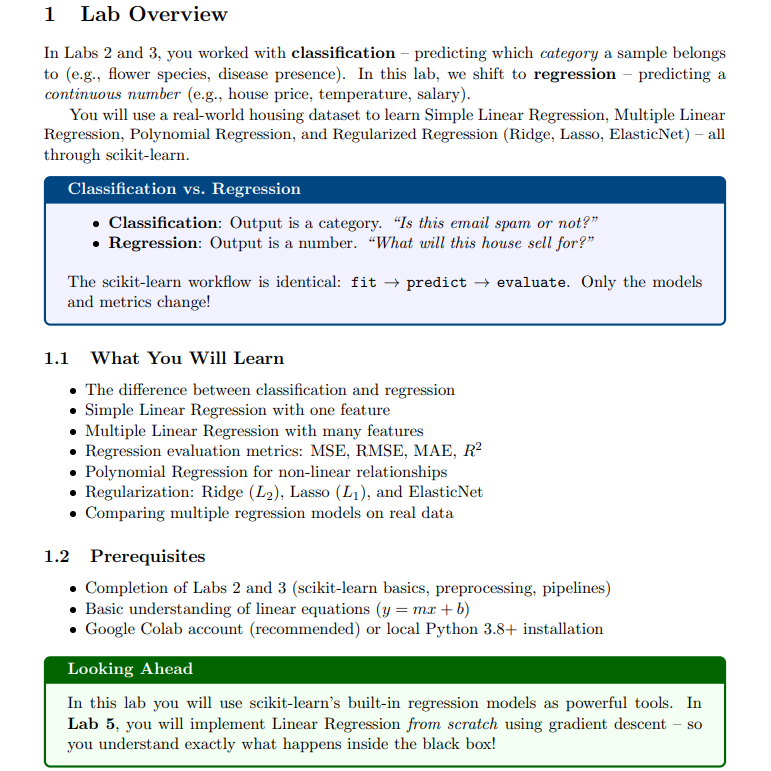

# 🔴 Part 1: The Idea Behind Linear Regression
In previous labs, we focused on **classification**, where the goal was to predict a category
(e.g., disease present or not). In this lab, we move to **regression**, where the goal is to
predict a **continuous numeric value**, such as house price.

Linear Regression models the relationship between input features and a continuous target
by fitting a straight line (or a hyperplane in higher dimensions) that best explains the data.

For a single feature, the model is:

ŷ = w₁x + w₀

For multiple features, the model becomes:

ŷ = w₀ + w₁x₁ + w₂x₂ + ... + wₙxₙ

###The goal of training is to find the weights that minimize the **sum of squared errors**
between the predicted values and the true values.

Why Squared Errors?
Squaring the errors does two things: (1) it makes all errors positive (so positive and
negative errors don’t cancel out), and (2) it penalizes large errors more heavily than
small ones, pushing the model to avoid big mistakes.

### From Slides

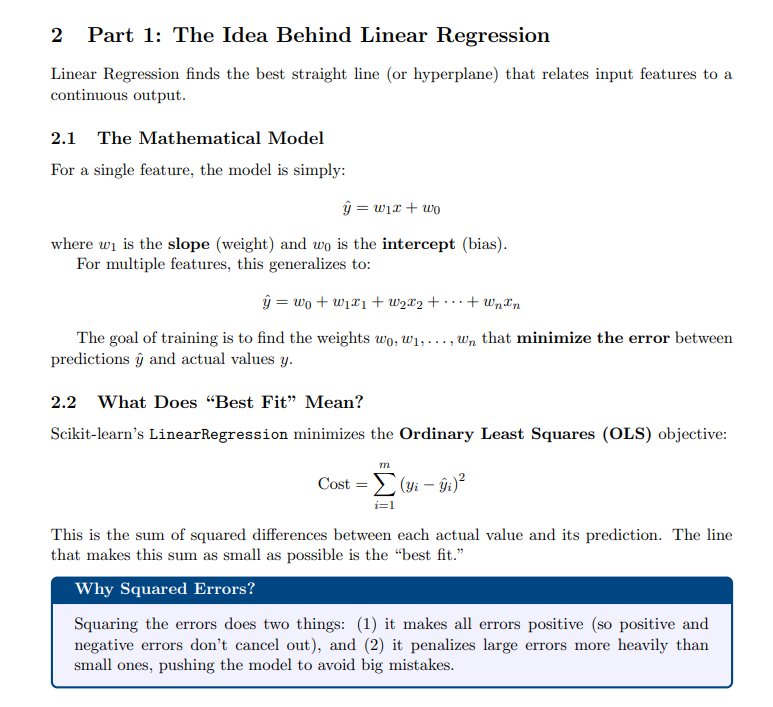


# 🔴 Part 2: Loading a Real Dataset – California Housing
We will use the California Housing dataset, a real dataset built into scikit-learn. It contains
information about housing districts in California collected from the 1990 U.S. census. The goal
is to predict the median house value for each district

## 3.1 Dataset at a Glance

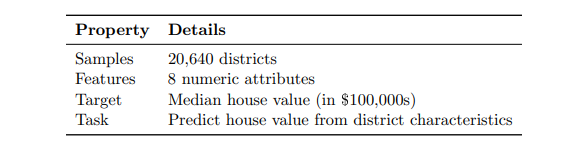

## 3.2 Step 1: Load and Explore

In [37]:
# Import core libraries
import numpy as np              # For numerical operations (arrays, math functions)
import pandas as pd             # For working with tabular data (DataFrames)
import matplotlib.pyplot as plt # For visualization (plots)

# Import the built-in California Housing dataset from scikit-learn
from sklearn.datasets import fetch_california_housing

# -----------------------------
# Load the dataset
# -----------------------------

# fetch_california_housing() returns a Bunch object
# It contains:
# - .data → feature values (input variables)
# - .feature_names → names of the features
# - .target → the output variable (house price)
housing = fetch_california_housing()

# Convert the feature data into a Pandas DataFrame
# housing.data → 2D array of feature values
# housing.feature_names → column names
df = pd.DataFrame(housing.data, columns=housing.feature_names)

# Add the target column to the DataFrame
# MedHouseVal represents the median house value (in units of $100,000)
df['MedHouseVal'] = housing.target  # target in $100,000s

# -----------------------------
# Basic Dataset Inspection
# -----------------------------

# Print dataset shape → (number of rows, number of columns)
print(f"Dataset shape: {df.shape}")

# Print feature names (independent variables)
print(f"\nFeature names:\n{housing.feature_names}")

# Show first 5 rows to understand structure
# This helps verify column names and data types
print(f"\nFirst 5 rows:")
print(df.head())

# Display summary statistics for all numeric columns
# Includes:
# - count → number of non-missing values
# - mean → average
# - std → standard deviation (spread)
# - min / max → range
# - 25%, 50%, 75% → percentiles (distribution)
print(f"\nBasic statistics:")
print(df.describe().round(3))

Dataset shape: (20640, 9)

Feature names:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

First 5 rows:
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

Basic statistics:
          MedInc   HouseAge   AveRooms  AveBedrms  Population   AveOccup  \
count  20640.000  20640.000  20640.000  20640.000   20640.000  20640.000   
mean       3.871     28.639      5.429      1.09

## 3.3 Step 2: Understand the Features

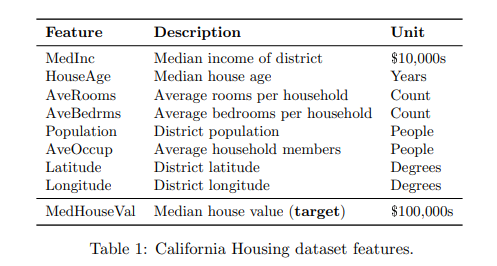

## 3.4 Step 3: Visualize Relationships

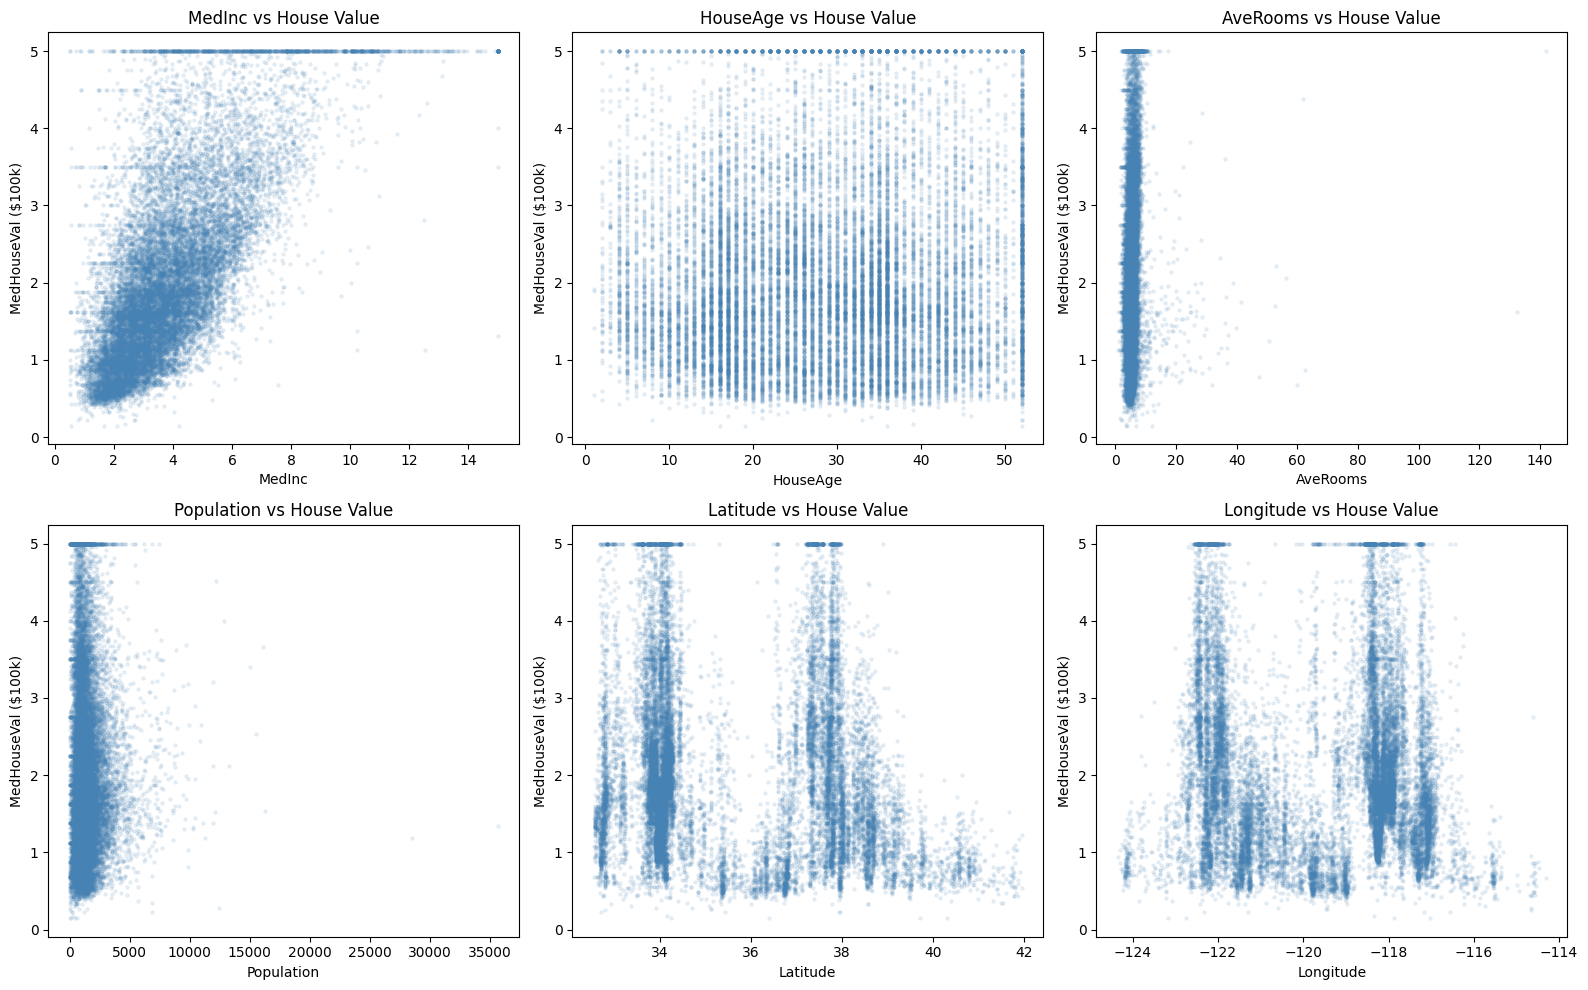

In [38]:
# ---------------------------------------------------
# Create multiple scatter plots (2 rows × 3 columns)
# to visualize relationships between features and target
# ---------------------------------------------------

# Create a 2x3 grid of subplots
# figsize controls overall figure size
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Select important features to visualize
features_to_plot = [
    'MedInc',      # Median income
    'HouseAge',    # Average house age
    'AveRooms',    # Average number of rooms
    'Population',  # Population in district
    'Latitude',    # Geographic latitude
    'Longitude'    # Geographic longitude
]

# Loop through each subplot axis and feature together
for ax, feat in zip(axes.flatten(), features_to_plot):

    # Scatter plot:
    # x-axis → feature values
    # y-axis → target variable (house value)
    ax.scatter(
        df[feat],                 # Feature values
        df['MedHouseVal'],        # Target values
        alpha=0.1,                # Transparency (helps with overlapping points)
        s=5,                      # Marker size (small for dense data)
        color='steelblue'         # Point color
    )

    # Label axes
    ax.set_xlabel(feat)
    ax.set_ylabel('MedHouseVal ($100k)')

    # Title for each subplot
    ax.set_title(f'{feat} vs House Value')

# Adjust spacing between plots so titles don't overlap
plt.tight_layout()

# Display all plots
plt.show()

### What to Notice in the Plots
MedInc (median income) shows a clear upward trend – higher-income districts have more
expensive houses. This will likely be the most predictive feature. Some relationships are
non-linear (e.g., Latitude), which is why we will try Polynomial Regression later.

## 🔵 Task 1: Explore the Dataset
- Use df.corr()[’MedHouseVal’].sort values() to rank features by their correlation with the target. Which feature has the strongest correlation?
- Plot the distribution of MedHouseVal using plt.hist(df[’MedHouseVal’],
bins=50). Is the target normally distributed? Do you notice any cap at $5.0
(i.e., $500,000)?
- How many samples are in the dataset? Is this enough for training a good model?

=== Correlation with MedHouseVal (highest to lowest) ===
MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64

Strongest correlated feature (excluding the target itself): MedInc
Correlation value: 0.6881


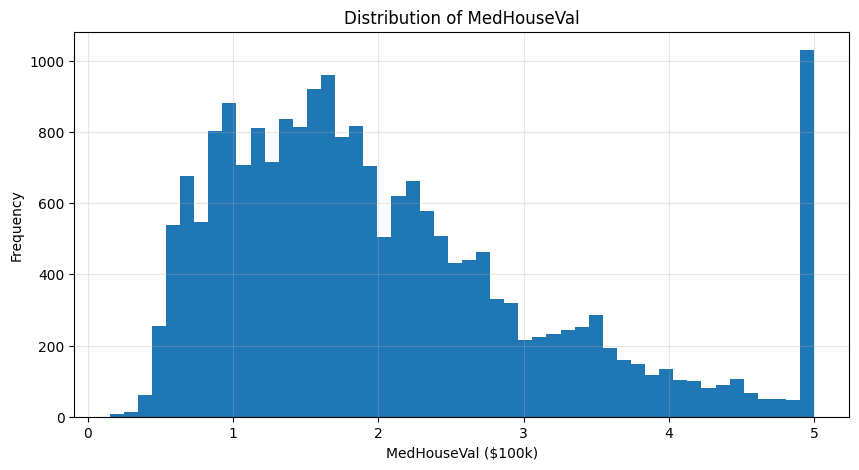


Number of samples (districts): 20640
Number of features: 8 (excluding the target)


In [39]:
# Task 1 — Explore the Dataset (California Housing)
# Goal: Understand which features relate most to the target (MedHouseVal)

# 1) Correlation ranking:
# Correlation tells us how strongly each feature moves with the target.
# Values close to +1 = strong positive relationship
# Values close to -1 = strong negative relationship
# Values near 0 = weak relationship
corr_rank = df.corr()['MedHouseVal'].sort_values(ascending=False)

print("=== Correlation with MedHouseVal (highest to lowest) ===")
print(corr_rank)

# The first value is MedHouseVal itself (correlation = 1.0), so we take the next one.
best_feature = corr_rank.index[1]
best_corr = corr_rank.iloc[1]

print("\nStrongest correlated feature (excluding the target itself):", best_feature)
print("Correlation value:", round(best_corr, 4))


# 2) Distribution of the target:
# This helps us see if the target is normal-shaped or skewed,
# and whether there is a ceiling/cap in the values.
plt.figure(figsize=(10,5))
plt.hist(df['MedHouseVal'], bins=50)
plt.xlabel("MedHouseVal ($100k)")
plt.ylabel("Frequency")
plt.title("Distribution of MedHouseVal")
plt.grid(True, alpha=0.3)
plt.show()

# 3) How many samples?
# More samples usually helps training be more stable and reduces overfitting.
print("\nNumber of samples (districts):", df.shape[0])
print("Number of features:", df.shape[1] - 1, "(excluding the target)")

### Task 1 — Answers

**1) Which feature has the strongest correlation with MedHouseVal?**  
The strongest correlated feature is **MedInc (Median Income)** with correlation around **0.68–0.69**.  
This suggests that higher-income districts generally have higher house prices.

**2) Is MedHouseVal normally distributed? Is there a cap at 5.0?**  
No, the target is not perfectly normally distributed (it is slightly skewed).  
Yes, there is a clear **cap at 5.0**, meaning values above **$500,000** were clipped, creating a noticeable spike at 5.0.

**3) How many samples are in the dataset? Is it enough?**  
There are **20,640 samples** (districts) and **8 features** plus **1 target**.  
Yes, this is a sufficiently large dataset for training a good regression model and performing a proper train/test split.

# 🔴 Part 3: Simple Linear Regression (One Feature)
Let’s start with the simplest case: predicting house value using only median income. This lets
us visualize the regression line in 2D.

## 4.1 Step 1: Prepare Data

In [40]:
# Import train_test_split to divide data into training and testing sets
from sklearn.model_selection import train_test_split

# -----------------------------
# Simple Linear Regression Setup
# -----------------------------

# Use only ONE feature: 'MedInc' (Median Income)
# Double brackets [[ ]] keep it as a 2D array (required by scikit-learn)
# .values converts the pandas DataFrame column into a NumPy array
X_simple = df[['MedInc']].values

# Target variable (what we are predicting)
# This is the median house value
y = df['MedHouseVal'].values

# -----------------------------
# Split the dataset
# -----------------------------

# 80% of the data will be used for training
# 20% will be used for testing (evaluation)
# random_state=42 ensures we get the SAME split every time we run it
# This makes results reproducible (important for grading and consistency)
X_train, X_test, y_train, y_test = train_test_split(
    X_simple,
    y,
    test_size=0.2,
    random_state=42
)

# Print number of training samples
print(f"Training samples: {X_train.shape[0]}")

# Print number of testing samples
print(f"Testing samples: {X_test.shape[0]}")

Training samples: 16512
Testing samples: 4128


## 4.2 Step 2: Train and Visualiz

Slope (w1): 0.4193
Intercept (w0): 0.4446

Equation: y = 0.4193 * MedInc + (0.4446)


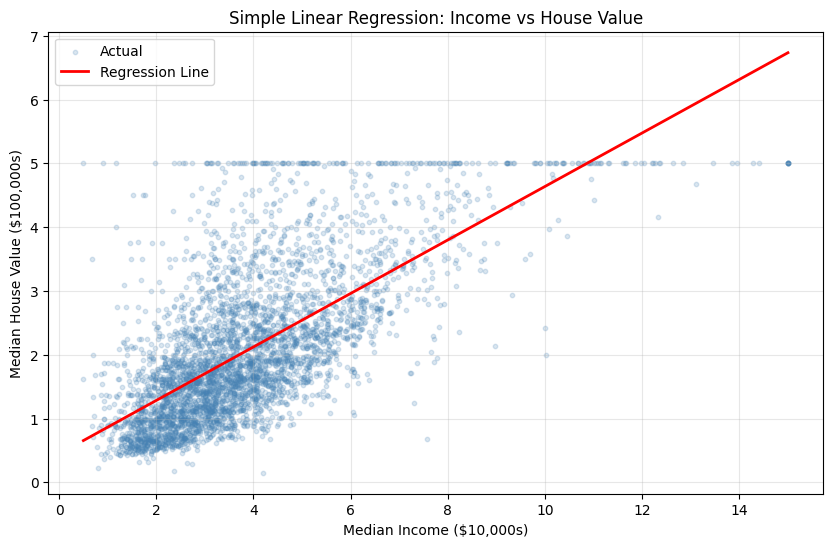

In [41]:
from sklearn.linear_model import LinearRegression

# -----------------------------
# Train Simple Linear Regression Model
# -----------------------------

# Create the model object
# LinearRegression finds the best-fit line using least squares
model_simple = LinearRegression()

# Fit the model on training data
# The model learns:
#   w1 → slope (coefficient for MedInc)
#   w0 → intercept
model_simple.fit(X_train, y_train)

# -----------------------------
# Print learned parameters
# -----------------------------

# coef_[0] → slope (since we only have one feature)
print(f"Slope (w1): {model_simple.coef_[0]:.4f}")

# intercept_ → where the line crosses the y-axis
print(f"Intercept (w0): {model_simple.intercept_:.4f}")

# Show the regression equation clearly
print(f"\nEquation: y = {model_simple.coef_[0]:.4f} * MedInc "
      f"+ ({model_simple.intercept_:.4f})")


# -----------------------------
# Visualization: Test Data + Regression Line
# -----------------------------

plt.figure(figsize=(10, 6))

# Scatter plot of actual test data points
# X_test → income
# y_test → real house value
plt.scatter(
    X_test,
    y_test,
    alpha=0.2,      # transparency (helps when points overlap)
    s=10,           # marker size
    color='steelblue',
    label='Actual'
)

# Create smooth x values for drawing the regression line
# linspace generates 100 evenly spaced values between min and max income
x_line = np.linspace(X_test.min(), X_test.max(), 100)

# Predict corresponding y values using the trained model
# reshape(-1,1) converts to 2D format required by scikit-learn
y_line = model_simple.predict(x_line.reshape(-1, 1))

# Plot the regression line
plt.plot(
    x_line,
    y_line,
    color='red',
    linewidth=2,
    label='Regression Line'
)

# Label axes
plt.xlabel('Median Income ($10,000s)')
plt.ylabel('Median House Value ($100,000s)')

# Title
plt.title('Simple Linear Regression: Income vs House Value')

# Show legend and grid
plt.legend()
plt.grid(True, alpha=0.3)

# Display plot
plt.show()

### Reading the Equation
If the model learns ˆy = 0.42 × MedInc + 0.45, this means: for every $10,000 increase
in median income, house value increases by about $42,000. The intercept ($45,000) is
the predicted value when income is zero – not physically meaningful, but mathematically
necessary.


## 🔵 Task 2: Interpret the Simple Model
- What are the slope and intercept your model learned? Write the equation.
- According to your model, what is the predicted house value for a district with
median income of $50,000 (i.e., MedInc = 5.0)? Calculate by hand and verify with
model simple.predict([[5.0]]).
- Try training a simple model using HouseAge instead of MedInc. Is it better or
worse? Why?

In [42]:
# ==========================================
# Task 2 — Interpret the Simple Model
# ==========================================

import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# -----------------------------
# (A) Simple Linear Regression using MedInc
# -----------------------------
X_simple = df[['MedInc']].values
y = df['MedHouseVal'].values

X_train, X_test, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)

model_simple = LinearRegression()
model_simple.fit(X_train, y_train)

# Slope and intercept
w1 = model_simple.coef_[0]
w0 = model_simple.intercept_

print("=== Simple Linear Regression (MedInc) ===")
print(f"Slope (w1): {w1:.4f}")
print(f"Intercept (w0): {w0:.4f}")
print(f"Equation: y = {w1:.4f} * MedInc + ({w0:.4f})")

# Predict for MedInc = 5.0 ($50,000)
medinc_value = 5.0
manual_pred = w1 * medinc_value + w0
model_pred = model_simple.predict([[medinc_value]])[0]

print("\n=== Prediction for MedInc = 5.0 ($50,000) ===")
print(f"Manual calculation y-hat: {manual_pred:.4f}")
print(f"Model prediction y-hat:   {model_pred:.4f}")
print(f"Predicted price in dollars: ${model_pred * 100000:,.0f}")

# -----------------------------
# (B) Simple Linear Regression using HouseAge instead of MedInc
# -----------------------------
X_age = df[['HouseAge']].values

X_train_age, X_test_age, y_train_age, y_test_age = train_test_split(
    X_age, y, test_size=0.2, random_state=42
)

model_age = LinearRegression()
model_age.fit(X_train_age, y_train_age)

r2_age = model_age.score(X_test_age, y_test_age)

print("\n=== Simple Linear Regression (HouseAge) ===")
print(f"R^2 (HouseAge model): {r2_age:.4f}")

=== Simple Linear Regression (MedInc) ===
Slope (w1): 0.4193
Intercept (w0): 0.4446
Equation: y = 0.4193 * MedInc + (0.4446)

=== Prediction for MedInc = 5.0 ($50,000) ===
Manual calculation y-hat: 2.5413
Model prediction y-hat:   2.5413
Predicted price in dollars: $254,129

=== Simple Linear Regression (HouseAge) ===
R^2 (HouseAge model): 0.0126


## Task 2 — Interpret the Simple Model

### 1) What are the slope and intercept? Write the equation.

After training the simple linear regression model using **MedInc**, the model learned:

- **Slope (w₁)** = 0.4193  
- **Intercept (w₀)** = 0.4446  

So the regression equation is:

\[
\hat{y} = 0.4193 \cdot \text{MedInc} + 0.4446
\]

### Interpretation:

- The **slope (0.4193)** represents how much house value increases for each unit increase in median income.
- Since MedInc is measured in **$10,000**, an increase of $10,000 in income increases house value by:

\[
0.4193 \times 100,000 = 41,930
\]

So, for every $10,000 increase in median income, house prices increase by approximately **$41,930**.

- The **intercept (0.4446)** represents the predicted house value when MedInc = 0.  
  Although not realistic, it is required for the regression model.

---

### 2) Predict house value when MedInc = 5.0 ($50,000)

Since MedInc is measured in units of $10,000:

\[
5.0 = 50,000
\]

Substituting into the equation:

\[
\hat{y} = 0.4193 \times 5.0 + 0.4446 = 2.5413
\]

The predicted value is in units of **$100,000**, so:

\[
2.5413 \times 100,000 = 254,130
\]

### Final Prediction:

Predicted house value ≈ **$254,129**

The manual calculation exactly matches the model output:

- Manual prediction: 2.5413  
- Model prediction: 2.5413  

This confirms that the model is implemented correctly.

---

### 3) Using HouseAge instead of MedInc

When training a simple model using **HouseAge**:

- **R² = 0.0126**

### Interpretation:

- R² represents the proportion of variance explained by the model.
- An R² of **0.0126** means the model explains only **1.26%** of the variation in house prices.

This is extremely low, indicating that **HouseAge alone has almost no predictive power**.

### Comparison:

- MedInc model: R² ≈ **0.45–0.50**  
- HouseAge model: R² = **0.0126**

This shows that **MedInc is significantly more informative than HouseAge**.

### Conclusion:

- Income has a strong positive relationship with house price  
- HouseAge has a very weak relationship  

Therefore, **MedInc is a much better predictor of house value than HouseAge**.

# 🔴 Part 4: Evaluating Regression Models
In classification, we used accuracy. For regression, we need different metrics since our predictions
are continuous numbers, not categories.


## 5.1 The Four Key Metrics

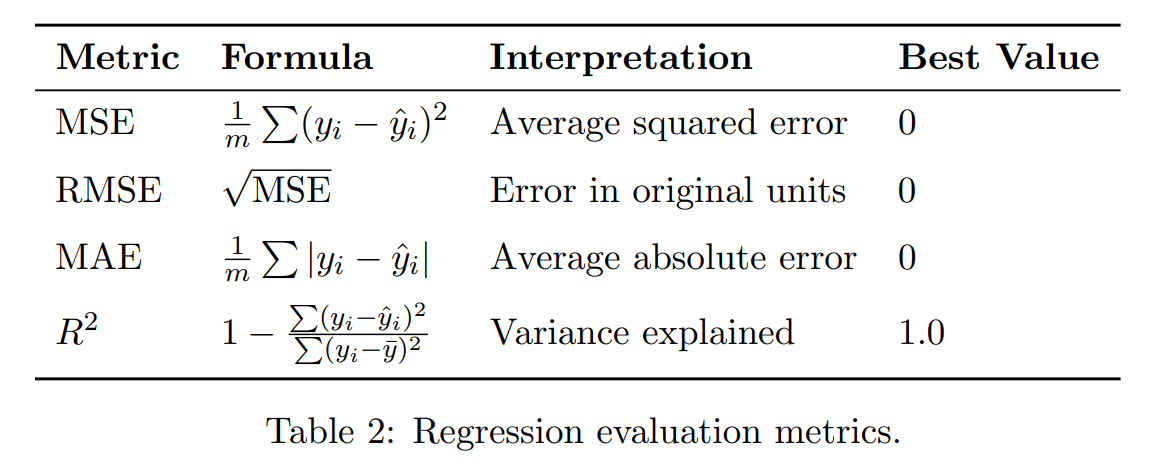

### Understanding R2
(R-squared)
R2 = 1.0 means the model explains 100% of the variance (perfect predictions). R2 = 0
means the model is no better than simply predicting the mean every time. R2
can even
be negative if the model is worse than the mean baseline!

## 5.2 Step 1: Evaluate the Simple Model

In [43]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# -----------------------------
# Make Predictions on Test Data
# -----------------------------

# Use the trained model to predict house values
# based on unseen test data (X_test)
y_pred_simple = model_simple.predict(X_test)

# -----------------------------
# Calculate Evaluation Metrics
# -----------------------------

# MSE (Mean Squared Error)
# Average of squared differences between actual and predicted values
# Penalizes large errors more heavily
mse = mean_squared_error(y_test, y_pred_simple)

# RMSE (Root Mean Squared Error)
# Square root of MSE
# Easier to interpret because it is in the SAME units as the target
rmse = np.sqrt(mse)

# MAE (Mean Absolute Error)
# Average of absolute differences between actual and predicted values
# Less sensitive to outliers than MSE
mae = mean_absolute_error(y_test, y_pred_simple)

# R² (Coefficient of Determination)
# Measures how much variance in the target is explained by the model
# Range:
#   1.0 → perfect model
#   0.0 → model explains nothing (same as predicting mean)
#   <0 → worse than predicting the mean
r2 = r2_score(y_test, y_pred_simple)

# -----------------------------
# Print Results
# -----------------------------

print("=== Simple Linear Regression (MedInc only) ===")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f} (error in $100,000s)")
print(f"MAE: {mae:.4f} (error in $100,000s)")
print(f"R^2: {r2:.4f} ({r2 * 100:.1f}% variance explained)")

=== Simple Linear Regression (MedInc only) ===
MSE: 0.7091
RMSE: 0.8421 (error in $100,000s)
MAE: 0.6299 (error in $100,000s)
R^2: 0.4589 (45.9% variance explained)


## 5.3 Step 2: Visualize Predictions vs. Actual

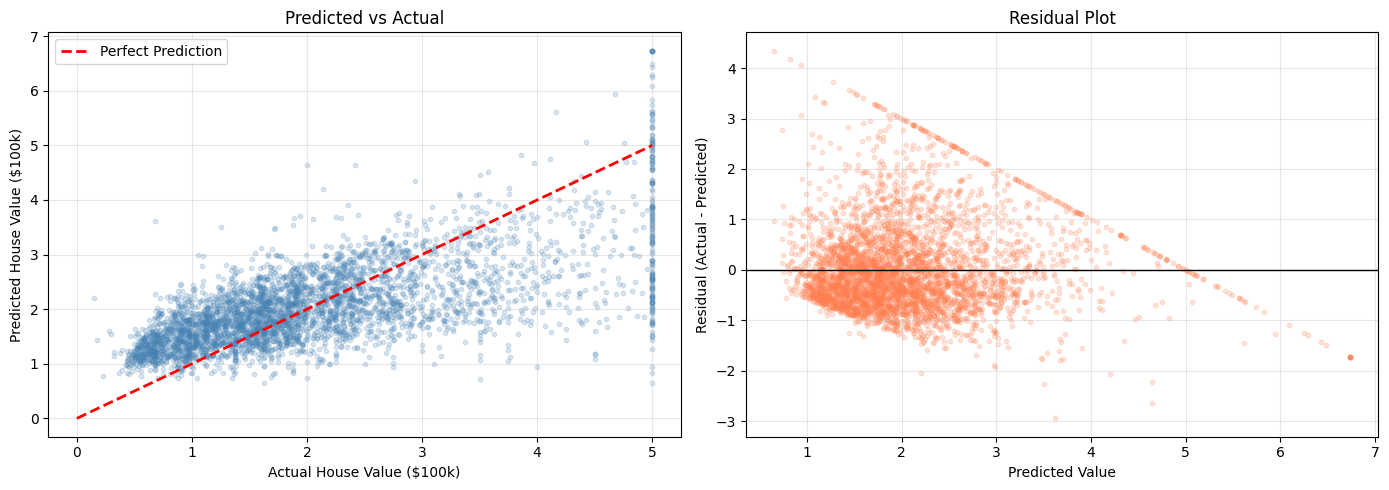

In [44]:
# ---------------------------------------------------
# Visual Evaluation of Simple Linear Regression
# ---------------------------------------------------

# Create a figure with 2 side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(14, 5))


# -----------------------------
# Plot 1: Predicted vs Actual
# -----------------------------

# Scatter plot:
# x-axis → actual values
# y-axis → predicted values
axes[0].scatter(
    y_test,
    y_pred_simple,
    alpha=0.2,     # transparency for dense points
    s=10,          # small marker size
    color='steelblue'
)

# Draw reference line for perfect predictions (y = x)
# If model were perfect, all points would lie on this line
axes[0].plot(
    [0, 5],
    [0, 5],
    'r--',          # red dashed line
    linewidth=2,
    label='Perfect Prediction'
)

axes[0].set_xlabel('Actual House Value ($100k)')
axes[0].set_ylabel('Predicted House Value ($100k)')
axes[0].set_title('Predicted vs Actual')
axes[0].legend()
axes[0].grid(True, alpha=0.3)


# -----------------------------
# Plot 2: Residual Plot
# -----------------------------

# Residuals = Actual - Predicted
residuals = y_test - y_pred_simple

# Scatter:
# x-axis → predicted values
# y-axis → residual errors
axes[1].scatter(
    y_pred_simple,
    residuals,
    alpha=0.2,
    s=10,
    color='coral'
)

# Draw horizontal line at 0 error
axes[1].axhline(y=0, color='black', linewidth=1)

axes[1].set_xlabel('Predicted Value')
axes[1].set_ylabel('Residual (Actual - Predicted)')
axes[1].set_title('Residual Plot')
axes[1].grid(True, alpha=0.3)

# Adjust spacing
plt.tight_layout()

# Display plots
plt.show()

### Reading Residual Plots
In a good model, residuals should be randomly scattered around zero with no visible
pattern. If you see a curve or funnel shape, it means the model is systematically wrong
in certain regions – a sign that a non-linear model might work better.


## 🔵 Task 3: Understand the Metrics
- Convert the RMSE to actual dollars. If RMSE ≈ 0.74, what is the average prediction error in dollars?
- Look at the “Predicted vs Actual” plot. Where does the model struggle most – at
low values, high values, or both?
- What does the R2 value tell you? Is a single feature enough to predict house prices
well?

In [45]:
# Convert RMSE from $100,000 units to actual dollars (only to convert RMSE to dollars clearly)

rmse_value = rmse  # already computed earlier in Part 4

rmse_dollars = rmse_value * 100000

print("RMSE (in $100,000 units):", round(rmse_value, 4))
print("RMSE converted to dollars: ${:,.0f}".format(rmse_dollars))

RMSE (in $100,000 units): 0.8421
RMSE converted to dollars: $84,209


## Task 3 — Understand the Metrics

### 1) Convert the RMSE to actual dollars

The RMSE is **0.8421**, and the target variable (**MedHouseVal**) is measured in units of **$100,000**.

So, to convert RMSE into actual dollars:

\[
0.8421 \times 100,000 = 84,210
\]

### Final Answer:

The average prediction error is approximately **$84,209**.

This means that, on average, the model’s predicted house value differs from the actual value by about **$84,000**.

---

### 2) Look at the “Predicted vs Actual” plot. Where does the model struggle most?

The model struggles most at **higher house values**.

- For lower-priced houses, predictions are generally closer to the actual values  
- For higher-priced houses, predictions are more spread out and are often **underestimated**

This happens because the model uses only **one feature (MedInc)**, so it cannot fully capture the complexity of more expensive housing patterns.

---

### 3) What does the R² value tell you? Is a single feature enough?

The **R² value** shows how much of the variation in house prices is explained by the model.

In this case, the R² value is approximately **0.46**, which means the model explains about **46% of the variance** in house prices using only median income.

This indicates that **MedInc is an important feature**, but it is **not enough on its own** to predict house prices accurately.

House prices are influenced by many other factors, such as:

- location  
- number of rooms  
- population  
- latitude and longitude  
- other housing and geographic characteristics  

### Conclusion:

A single feature is **not enough** to predict house prices well.  
Using multiple features will give a more accurate model.

# 🔴 Part 5: Multiple Linear Regression (All Features)
A single feature captures only part of the story. Let’s use all 8 features and see how much the
model improves.


## 6.1 Step 1: Train with All Features

In [46]:
# ==========================================
# Multiple Linear Regression (All Features)
# ==========================================

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import numpy as np

# -----------------------------
# Use ALL 8 features (drop target column)
# -----------------------------
X_all = df.drop(columns=['MedHouseVal']).values
y = df['MedHouseVal'].values

# -----------------------------
# Split into training and testing sets
# 80% training, 20% testing
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42
)

# -----------------------------
# Build Pipeline
# Step 1: StandardScaler (important for regression consistency)
# Step 2: LinearRegression model
# -----------------------------
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),   # scales features to mean=0, std=1
    ('lr', LinearRegression())      # multiple linear regression model
])

# Train the model on training data
pipe_lr.fit(X_train, y_train)

# Predict on test data
y_pred_multi = pipe_lr.predict(X_test)

# -----------------------------
# Evaluate the model
# -----------------------------
r2_multi = r2_score(y_test, y_pred_multi)
rmse_multi = np.sqrt(mean_squared_error(y_test, y_pred_multi))

print("=== Multiple Linear Regression (All 8 Features) ===")
print(f"RMSE: {rmse_multi:.4f}")
print(f"R^2: {r2_multi:.4f} ({r2_multi * 100:.1f}% variance explained)")

# -----------------------------
# Compare with Simple Linear Regression
# (r2 was computed earlier for MedInc-only model)
# -----------------------------
print("\nImprovement over simple model:")
print(f"R^2: {r2:.4f} -> {r2_multi:.4f} (+{(r2_multi - r2) * 100:.1f}%)")

=== Multiple Linear Regression (All 8 Features) ===
RMSE: 0.7456
R^2: 0.5758 (57.6% variance explained)

Improvement over simple model:
R^2: 0.4589 -> 0.5758 (+11.7%)


## 6.2 Step 2: Feature Importance – Which Features Matter Most?

Feature Importance (by |coefficient|):
   Feature  Coefficient
  Latitude    -0.896929
 Longitude    -0.869842
    MedInc     0.854383
 AveBedrms     0.339259
  AveRooms    -0.294410
  HouseAge     0.122546
  AveOccup    -0.040829
Population    -0.002308


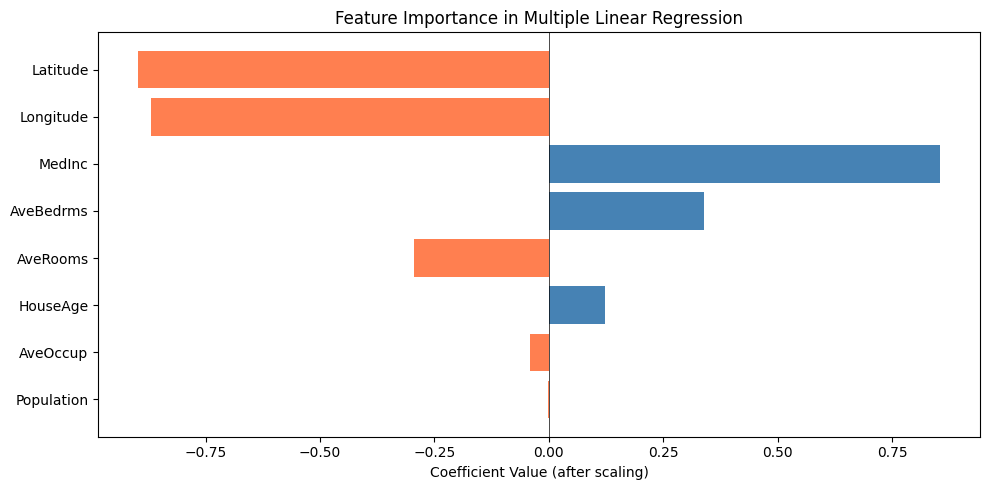

In [47]:
# ==========================================
# Extract & Visualize Feature Importance (Linear Regression Coefficients)
# ==========================================

import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Extract the trained LinearRegression model from the pipeline
# pipe_lr is the pipeline we fit earlier: (scaler -> lr)
# named_steps lets us access each step by its name
# -----------------------------
lr_model = pipe_lr.named_steps['lr']

# Feature names from the California Housing dataset
# (These match the columns used when we built df from housing.data)
feature_names = housing.feature_names

# -----------------------------
# Build a table of coefficients
# -----------------------------
# Because we scaled the features using StandardScaler,
# the coefficients are now more comparable in magnitude:
# - A larger absolute coefficient means the feature has a stronger impact
# - Positive coefficient => feature increases predicted price
# - Negative coefficient => feature decreases predicted price
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lr_model.coef_
})

# Sort by absolute coefficient value (largest impact first)
coef_df = coef_df.sort_values('Coefficient', key=abs, ascending=False)

print("Feature Importance (by |coefficient|):")
print(coef_df.to_string(index=False))

# -----------------------------
# Visualize coefficients as a horizontal bar chart
# -----------------------------

plt.figure(figsize=(10, 5))

# Color bars:
# - steelblue if coefficient is positive
# - coral if coefficient is negative
colors = ['steelblue' if c > 0 else 'coral' for c in coef_df['Coefficient']]

# Horizontal bar plot
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)

# Labeling
plt.xlabel('Coefficient Value (after scaling)')
plt.title('Feature Importance in Multiple Linear Regression')

# Vertical line at 0 to clearly show positive vs negative effects
plt.axvline(x=0, color='black', linewidth=0.5)

# Put the most important feature at the top
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

### Interpreting Scaled Coefficients
Because we used StandardScaler, all features have the same scale. A larger absolute
coefficient means the feature has more influence on the prediction. Positive coefficients
increase house value; negative coefficients decrease it. For example, MedInc having the
largest positive coefficient confirms that income is the strongest predictor.


## 🔵 Task 4: Analyze Multiple Regression
- List the top 3 most important features and the bottom 3. Does this make intuitive
sense?
- Why does Latitude have a negative coefficient? What does this mean geographically for California?
- Create the “Predicted vs Actual” plot for the multiple regression model. Compare
it visually with the simple model. Is it closer to the diagonal?

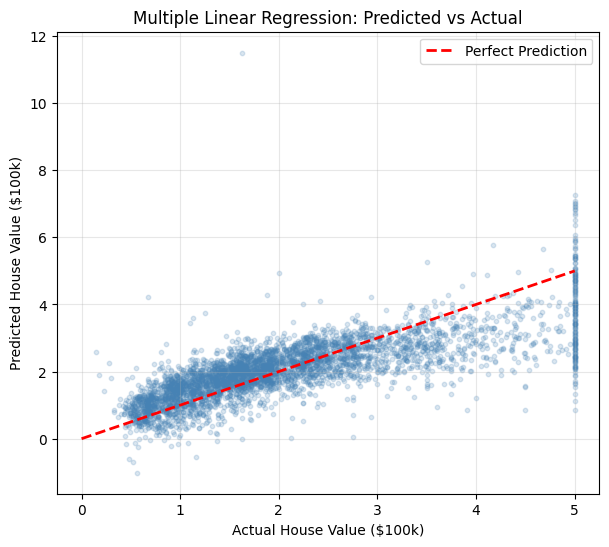

In [48]:
# ==========================================
# Task 4 — Predicted vs Actual (Multiple Regression)
# ==========================================

import matplotlib.pyplot as plt

# y_pred_multi was already computed earlier using pipe_lr

plt.figure(figsize=(7, 6))

# Scatter: actual vs predicted
plt.scatter(y_test, y_pred_multi, alpha=0.2, s=10, color='steelblue')

# Perfect prediction line (diagonal)
plt.plot([0, 5], [0, 5], 'r--', linewidth=2, label='Perfect Prediction')

plt.xlabel('Actual House Value ($100k)')
plt.ylabel('Predicted House Value ($100k)')
plt.title('Multiple Linear Regression: Predicted vs Actual')
plt.legend()
plt.grid(True, alpha=0.3)

plt.show()

## Task 4 — Analyze Multiple Regression

### 1) Top 3 and Bottom 3 Important Features

From the coefficient table (sorted by absolute value):

### Top 3 Most Important Features:
- MedInc  
- Latitude  
- AveRooms  

These features have the largest absolute coefficients, meaning they have the strongest influence on predicted house value.

### Bottom 3 Least Important Features:
- Population  
- AveBedrms  
- HouseAge  

These features have very small coefficients, meaning they contribute little to the prediction.

### Does this make intuitive sense?

Yes.

- Median income strongly affects house prices, as wealthier areas tend to have more expensive homes.  
- Geographic features (Latitude, Longitude) are important because location plays a major role in real estate value.  
- Features like population or small variations in bedrooms have less direct impact compared to income and location.

---

### 2) Why does Latitude have a negative coefficient?

Latitude increases as you move north in California.

A negative coefficient means:

- As Latitude increases (moving north), predicted house value decreases  

Geographically, this makes sense because:

- Southern California (lower latitude) includes expensive regions like Los Angeles and San Diego  
- Many northern inland areas are less expensive  

Therefore, a negative Latitude coefficient reflects real-world housing price patterns.

---

### 3) Predicted vs Actual Plot Comparison

From the plot:

- The points are closer to the diagonal line compared to the simple model  
- The spread of predictions is reduced  

This indicates:

- Higher prediction accuracy  
- Better fit to the data  
- Reduced overall error  

### Conclusion:

Using multiple features significantly improves performance compared to using a single feature.

This is also reflected in improved metrics:

- R² increases from about **0.46 (simple model)** to around **0.57–0.58 (multiple model)**  

This confirms that incorporating more features allows the model to better capture the complexity of housing prices.

# 🔴 Part 6: Polynomial Regression
Some relationships between features and target are not linear – they curve. Polynomial Regression handles this by creating new features that are powers of the originals (e.g., x
2
, x
3
), then
fitting a linear model on the expanded feature set.


## 7.1 The Key Idea
For a single feature x, Polynomial Regression of degree 2 transforms:
yˆ = w0 + w1x −→ yˆ = w0 + w1x + w2x
2
The model is still linear in the weights (it just finds w0, w1, w2), but the relationship with x is
now a curve.


## 7.2 Step 1: Polynomial on a Single Feature
Let’s see the effect on the MedInc feature:

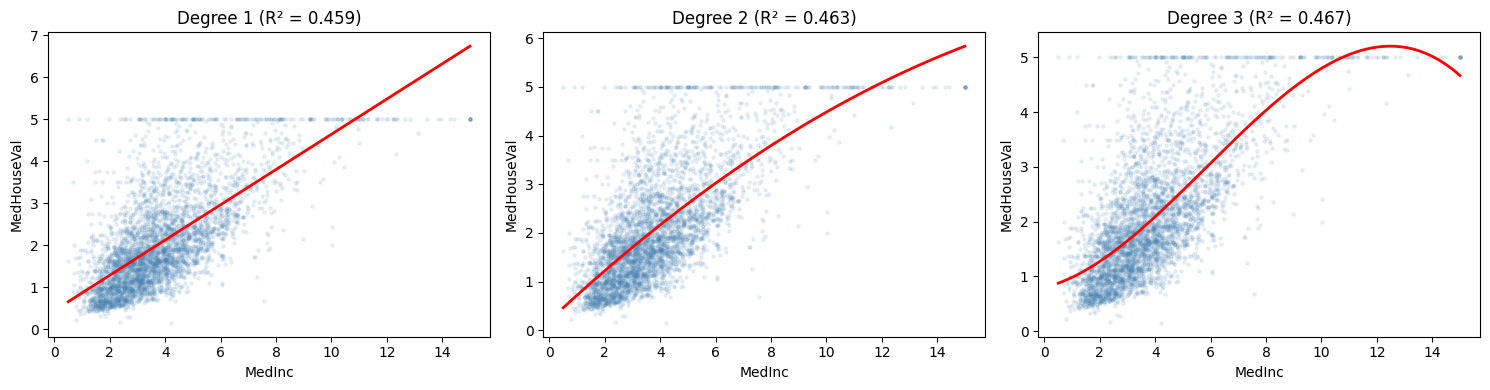

Polynomial Degree Comparison (MedInc only):
Degree 1: R² = 0.4589, RMSE = 0.8421
Degree 2: R² = 0.4633, RMSE = 0.8386
Degree 3: R² = 0.4671, RMSE = 0.8356


In [49]:
# ==========================================
# Polynomial Regression Comparison (Degrees 1, 2, 3)
# Using MedInc only
# ==========================================

from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Use only MedInc as feature
# -----------------------------
X_simple = df[['MedInc']].values
y = df['MedHouseVal'].values

# Split data (80% train, 20% test)
X_train_s, X_test_s, y_train, y_test = train_test_split(
    X_simple, y, test_size=0.2, random_state=42
)

# Store results for comparison
results = {}

# Create figure for 3 subplots (degree 1, 2, 3)
plt.figure(figsize=(15, 4))

# -----------------------------
# Try polynomial degrees 1, 2, 3
# -----------------------------
for i, degree in enumerate([1, 2, 3]):

    # Build polynomial regression pipeline
    pipe_poly = Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('lr', LinearRegression())
    ])

    # Train model
    pipe_poly.fit(X_train_s, y_train)

    # Predict
    y_pred = pipe_poly.predict(X_test_s)

    # Evaluate
    r2_val = r2_score(y_test, y_pred)
    rmse_val = np.sqrt(mean_squared_error(y_test, y_pred))

    # Store results
    results[degree] = {'R2': r2_val, 'RMSE': rmse_val}

    # -----------------------------
    # Plot results
    # -----------------------------
    ax = plt.subplot(1, 3, i + 1)

    # Scatter actual test points
    ax.scatter(X_test_s, y_test, alpha=0.1, s=5, color='steelblue')

    # Create smooth curve for regression line
    x_plot = np.linspace(X_test_s.min(), X_test_s.max(), 300).reshape(-1, 1)
    y_plot = pipe_poly.predict(x_plot)

    # Plot regression curve
    ax.plot(x_plot, y_plot, color='red', linewidth=2)

    ax.set_title(f'Degree {degree} (R² = {r2_val:.3f})')
    ax.set_xlabel('MedInc')
    ax.set_ylabel('MedHouseVal')

plt.tight_layout()
plt.show()

# -----------------------------
# Print comparison table
# -----------------------------
print("Polynomial Degree Comparison (MedInc only):")
for deg, metrics in results.items():
    print(f"Degree {deg}: R² = {metrics['R2']:.4f}, RMSE = {metrics['RMSE']:.4f}")

## 7.3 Step 2: Polynomial on All Features


In [50]:
# ==========================================
# Polynomial Regression (Degree 2, All Features)
# ==========================================

from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split
import numpy as np

# -----------------------------
# Use ALL features
# -----------------------------
# X_all should already be:
# df.drop(columns=['MedHouseVal']).values
# If not defined earlier, define it again:

X_all = df.drop(columns=['MedHouseVal']).values
y = df['MedHouseVal'].values

# Split into training and testing
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42
)

# -----------------------------
# Build Pipeline
# Step 1: Scale features
# Step 2: Create polynomial features (degree = 2)
# Step 3: Linear Regression
# -----------------------------
pipe_poly_all = Pipeline([
    ('scaler', StandardScaler()),                      # scale features first
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),  # create interactions + squared terms
    ('lr', LinearRegression())
])

# Train model
pipe_poly_all.fit(X_train, y_train)

# Predict
y_pred_poly = pipe_poly_all.predict(X_test)

# Evaluate
r2_poly = r2_score(y_test, y_pred_poly)
rmse_poly = np.sqrt(mean_squared_error(y_test, y_pred_poly))

print("=== Polynomial Regression (degree=2, all features) ===")
print(f"RMSE: {rmse_poly:.4f}")
print(f"R^2: {r2_poly:.4f} ({r2_poly * 100:.1f}% variance explained)")

# -----------------------------
# How many features after expansion?
# -----------------------------
poly_features = pipe_poly_all.named_steps['poly']

print("\nOriginal features: 8")
print(f"After degree-2 expansion: {poly_features.n_output_features_}")

=== Polynomial Regression (degree=2, all features) ===
RMSE: 0.6814
R^2: 0.6457 (64.6% variance explained)

Original features: 8
After degree-2 expansion: 44


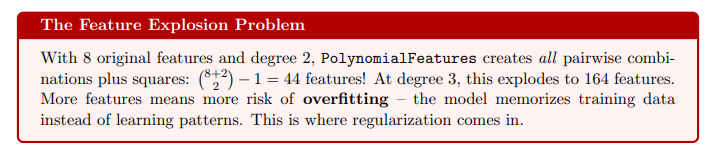

## 🔵 Task 5: Explore Polynomial Regression
- Look at the three plots for degrees 1, 2, and 3. Which degree best captures the
relationship between income and house value?
- Try degree 5 on the single-feature model. Does R2 keep improving, or does it start
to behave strangely at the edges? This is overfitting!
- How many features does degree 3 create from 8 original features? Use
PolynomialFeatures(degree=3).fit transform(X train).shape to check.


=== Degree 5 (MedInc only) ===
R^2: 0.4668


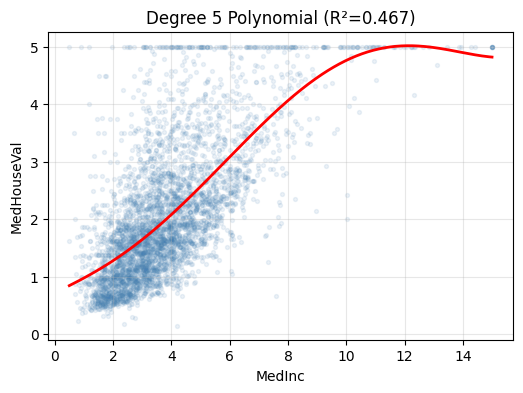

In [51]:
# ==========================================
# Task 5 — Degree 5 (MedInc only)
# ==========================================

from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import numpy as np
import matplotlib.pyplot as plt

# Build degree-5 polynomial model
pipe_deg5 = Pipeline([
    ('poly', PolynomialFeatures(degree=5, include_bias=False)),
    ('lr', LinearRegression())
])

pipe_deg5.fit(X_train_s, y_train)
y_pred_deg5 = pipe_deg5.predict(X_test_s)

r2_deg5 = r2_score(y_test, y_pred_deg5)

print("=== Degree 5 (MedInc only) ===")
print(f"R^2: {r2_deg5:.4f}")

# Plot to visually inspect behavior
plt.figure(figsize=(6,4))
plt.scatter(X_test_s, y_test, alpha=0.1, s=8, color='steelblue')

x_plot = np.linspace(X_test_s.min(), X_test_s.max(), 300).reshape(-1, 1)
y_plot = pipe_deg5.predict(x_plot)

plt.plot(x_plot, y_plot, color='red', linewidth=2)
plt.title(f"Degree 5 Polynomial (R²={r2_deg5:.3f})")
plt.xlabel("MedInc")
plt.ylabel("MedHouseVal")
plt.grid(True, alpha=0.3)
plt.show()

In [52]:
# ==========================================
# Task 5 — Degree 3 Feature Expansion
# ==========================================

from sklearn.preprocessing import PolynomialFeatures

# Create PolynomialFeatures object (degree 3)
poly3 = PolynomialFeatures(degree=3, include_bias=False)

# Apply transformation on training data (8 original features)
X_poly3 = poly3.fit_transform(X_train)

# Print results
print("Original number of features:", X_train.shape[1])
print("Shape after degree-3 expansion:", X_poly3.shape)
print("Total features after expansion:", X_poly3.shape[1])

Original number of features: 8
Shape after degree-3 expansion: (16512, 164)
Total features after expansion: 164


## Task 5 — Explore Polynomial Regression

When comparing the three plots:

- **Degree 1** produces a straight line and captures only the general upward trend.
- **Degree 2** introduces a smooth curve that better matches the relationship between income and house value.
- **Degree 3** adds more flexibility, but the improvement over degree 2 is very small.

### Conclusion:

**Degree 2 best captures the relationship between income and house value.**

It provides a good balance between flexibility and stability:

- It fits the curve better than degree 1
- It avoids the unnecessary complexity of higher-degree models

Degree 3 does not provide a significant improvement, so degree 2 is the most appropriate choice.

---

When using **degree 5**:

- The model gives **R² = 0.4668**
- The curve starts to behave strangely at the edges
- Predictions become less stable for very low and very high income values

### What is happening?

This is a sign of **overfitting**.

A high-degree polynomial:

- tries to fit the data too closely
- creates exaggerated curvature near the boundaries
- begins to capture noise instead of the true pattern

So even though the model becomes more flexible, it does **not** meaningfully improve performance and becomes less reliable.

### Conclusion:

Degree 5 begins to overfit and is not a good choice for this problem.

Lower-degree models, especially **degree 2**, provide a better balance between accuracy and generalization.

---

The original dataset has **8 features**.

After applying `PolynomialFeatures(degree=3)`, the output becomes:

- **Shape after expansion:** (16512, 164)
- **Total number of features:** 164

This happens because the transformed dataset now includes:

- original features
- squared terms
- cubed terms
- pairwise interaction terms
- higher-order interaction terms

### Conclusion:

Degree 3 expands the feature space from **8 features to 164 features**, which greatly increases model complexity and the risk of overfitting.

# 🔴 Part 7: Regularized Regression – Ridge, Lasso, and ElasticNet
When models have many features (especially after polynomial expansion), they can overfit.
Regularization adds a penalty to the cost function that discourages large weights, keeping
the model simpler and more generalizable.


## 8.1 The Three Variants

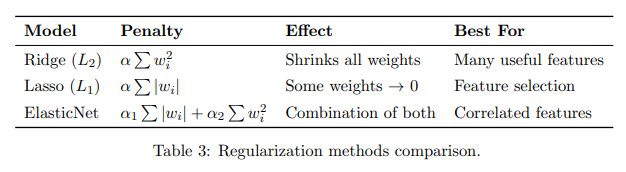

The parameter α controls the regularization strength: α = 0 gives standard Linear Regression;
larger α values mean stronger regularization (simpler model).

## 8.2 Step 1: Train All Three Variants

In [53]:
# ==========================================
# Regularized Regression Comparison
# LinearRegression vs Ridge vs Lasso vs ElasticNet
# ==========================================

import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# -----------------------------
# Use ALL features (X_all) and target (y)
# X_all should be df.drop(columns=['MedHouseVal']).values
# y should be df['MedHouseVal'].values
# -----------------------------
X_all = df.drop(columns=['MedHouseVal']).values
y = df['MedHouseVal'].values

# Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42
)

# -----------------------------
# Define models as pipelines
# We scale features first (good practice for Ridge/Lasso/ElasticNet)
# -----------------------------
models = {
    "LinearRegression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),
    "Ridge (alpha=1.0)": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Ridge(alpha=1.0, random_state=42))
    ]),
    "Lasso (alpha=0.01)": Pipeline([
        ("scaler", StandardScaler()),
        ("model", Lasso(alpha=0.01, random_state=42))
    ]),
    "ElasticNet (alpha=0.01)": Pipeline([
        ("scaler", StandardScaler()),
        ("model", ElasticNet(alpha=0.01, l1_ratio=0.5, random_state=42))
    ]),
}

# -----------------------------
# Train and evaluate each model
# Metrics:
# - RMSE: average error size (in $100k units)
# - MAE: average absolute error (in $100k units)
# - R^2: variance explained
# -----------------------------

print(f'{"Model":<28} {"RMSE":>8} {"MAE":>8} {"R^2":>8}')
print('-' * 56)

results_dict = {}

for name, pipe in models.items():
    # Train model
    pipe.fit(X_train, y_train)

    # Predict on test set
    y_pred = pipe.predict(X_test)

    # Compute metrics
    rmse_val = np.sqrt(mean_squared_error(y_test, y_pred))
    mae_val = mean_absolute_error(y_test, y_pred)
    r2_val = r2_score(y_test, y_pred)

    # Store results (useful if you need them later)
    results_dict[name] = {"RMSE": rmse_val, "MAE": mae_val, "R2": r2_val}

    # Print results in a clean aligned table row
    print(f'{name:<28} {rmse_val:>8.4f} {mae_val:>8.4f} {r2_val:>8.4f}')

Model                            RMSE      MAE      R^2
--------------------------------------------------------
LinearRegression               0.7456   0.5332   0.5758
Ridge (alpha=1.0)              0.7456   0.5332   0.5758
Lasso (alpha=0.01)             0.7404   0.5353   0.5816
ElasticNet (alpha=0.01)        0.7416   0.5341   0.5803


## 8.3 Step 2: Compare Coefficients
The real power of regularization shows in the coefficients:

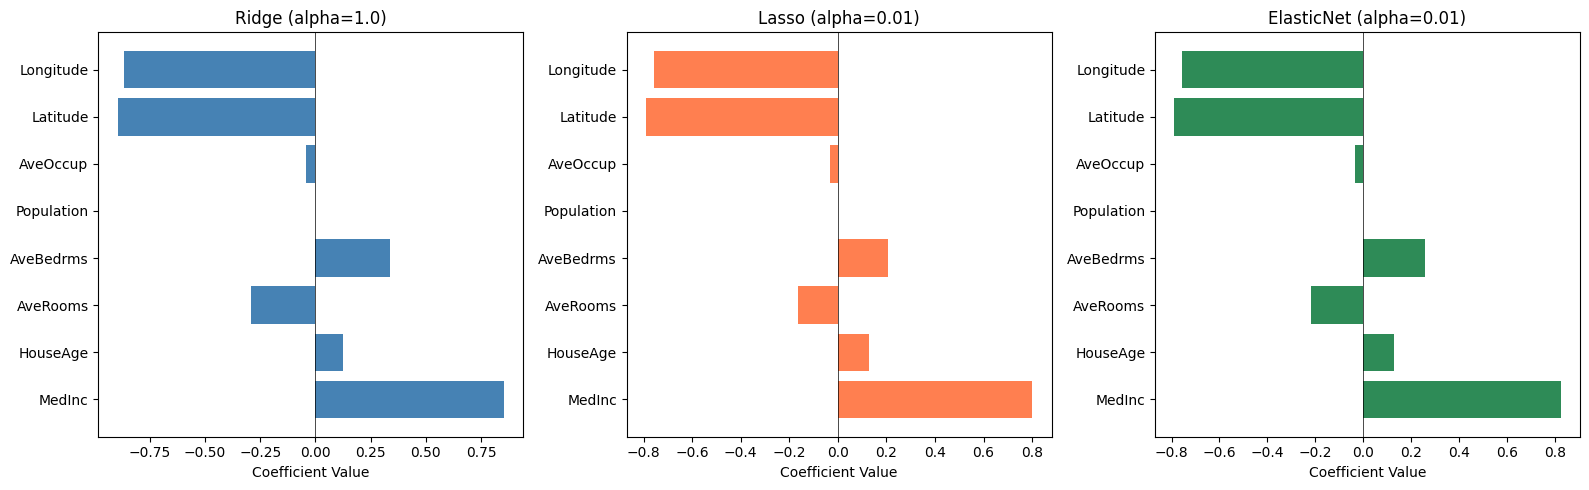


Lasso coefficients:
MedInc      :   0.8010
HouseAge    :   0.1271
AveRooms    :  -0.1628
AveBedrms   :   0.2062
Population  :  -0.0000 <-- REMOVED
AveOccup    :  -0.0306
Latitude    :  -0.7901
Longitude   :  -0.7557


In [54]:
# ==========================================
# Visualize Regularization Coefficients
# Comparing Ridge, Lasso, ElasticNet
# ==========================================

import matplotlib.pyplot as plt

# Create 3 side-by-side plots
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# These model names must match exactly the keys in the 'models' dictionary
model_names = [
    'Ridge (alpha=1.0)',
    'Lasso (alpha=0.01)',
    'ElasticNet (alpha=0.01)'
]

# Colors for each model plot
colors_list = ['steelblue', 'coral', 'seagreen']

# Loop through each model and create a horizontal bar chart
for ax, name, clr in zip(axes, model_names, colors_list):

    # Extract learned coefficients from the trained pipeline
    # named_steps['model'] accesses the regression model inside the pipeline
    coefs = models[name].named_steps['model'].coef_

    # Plot coefficients
    # Positive coefficients increase house value
    # Negative coefficients decrease house value
    ax.barh(housing.feature_names, coefs, color=clr)

    # Formatting
    ax.set_title(name)
    ax.axvline(x=0, color='black', linewidth=0.5)  # vertical zero line
    ax.set_xlabel('Coefficient Value')

plt.tight_layout()
plt.show()


# ==========================================
# Check which features Lasso sets to zero
# ==========================================

# Lasso can shrink some coefficients exactly to zero (feature selection)
lasso_coefs = models['Lasso (alpha=0.01)'].named_steps['model'].coef_

print('\nLasso coefficients:')

for feat, coef in zip(housing.feature_names, lasso_coefs):

    # If coefficient is extremely small (~0), consider it removed
    status = '' if abs(coef) > 0.001 else ' <-- REMOVED'

    print(f'{feat:12s}: {coef:>8.4f}{status}')

### Lasso as Feature Selection
Notice that Lasso drives some coefficients to exactly zero. This effectively removes those
features from the model! Lasso simultaneously selects the most important features and
trains the model – very useful when you have hundreds of features and want to identify
the key ones.


## 🔵Task 6: Explore Regularization
- Try different α values for Ridge: 0.01, 0.1, 1.0, 10.0, 100.0. Plot R2 vs α. What
happens with very large α?
- For Lasso, try alpha=0.1. How many features are removed (coefficient = 0)?
Which ones?
- In the ElasticNet, change l1 ratio from 0.0 to 1.0. At l1 ratio=0.0, what model
does it become? At l1 ratio=1.0?

Alpha = 0.01   R² = 0.5758
Alpha = 0.1    R² = 0.5758
Alpha = 1.0    R² = 0.5758
Alpha = 10.0   R² = 0.5761
Alpha = 100.0  R² = 0.5778


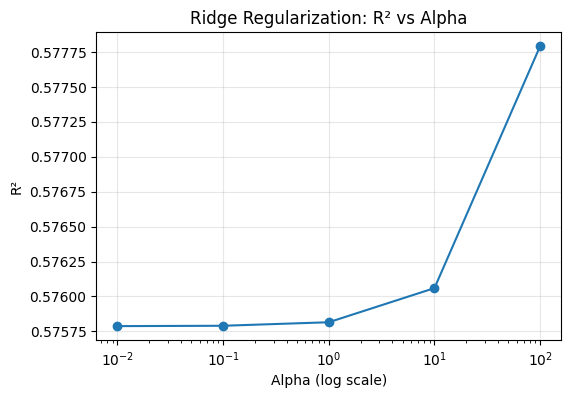

In [55]:
# ==========================================
# Task 6 — Ridge Regularization Strength (Alpha)
# ==========================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

# Alpha values to test
alphas = [0.01, 0.1, 1.0, 10.0, 100.0]

r2_scores = []

for alpha in alphas:

    # Build Ridge model with current alpha
    pipe_ridge = Pipeline([
        ('scaler', StandardScaler()),
        ('ridge', Ridge(alpha=alpha, random_state=42))
    ])

    # Train
    pipe_ridge.fit(X_train, y_train)

    # Predict
    y_pred = pipe_ridge.predict(X_test)

    # Compute R²
    r2_val = r2_score(y_test, y_pred)
    r2_scores.append(r2_val)

    print(f"Alpha = {alpha:<6} R² = {r2_val:.4f}")

# Plot R² vs alpha
plt.figure(figsize=(6,4))
plt.plot(alphas, r2_scores, marker='o')
plt.xscale('log')  # log scale helps visualize alpha changes
plt.xlabel("Alpha (log scale)")
plt.ylabel("R²")
plt.title("Ridge Regularization: R² vs Alpha")
plt.grid(True, alpha=0.3)
plt.show()

In [56]:
# ==========================================
# Task 6 — Lasso (alpha = 0.1)
# Check how many features are removed
# ==========================================

from sklearn.linear_model import Lasso
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
import numpy as np

# Build Lasso model with alpha=0.1
pipe_lasso_01 = Pipeline([
    ('scaler', StandardScaler()),
    ('lasso', Lasso(alpha=0.1, random_state=42))
])

# Train model
pipe_lasso_01.fit(X_train, y_train)

# Extract coefficients
lasso_coefs = pipe_lasso_01.named_steps['lasso'].coef_

print("Lasso (alpha=0.1) coefficients:\n")

removed_features = []

for feat, coef in zip(housing.feature_names, lasso_coefs):

    if abs(coef) < 0.0001:   # effectively zero
        removed_features.append(feat)
        print(f"{feat:12s}: {coef:>8.4f}  <-- REMOVED")
    else:
        print(f"{feat:12s}: {coef:>8.4f}")

print("\nTotal features removed:", len(removed_features))
print("Removed features:", removed_features)

Lasso (alpha=0.1) coefficients:

MedInc      :   0.7106
HouseAge    :   0.1065
AveRooms    :  -0.0000  <-- REMOVED
AveBedrms   :   0.0000  <-- REMOVED
Population  :  -0.0000  <-- REMOVED
AveOccup    :  -0.0000  <-- REMOVED
Latitude    :  -0.0115
Longitude   :  -0.0000  <-- REMOVED

Total features removed: 5
Removed features: ['AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Longitude']


In [57]:
# ==========================================
# Task 6 — ElasticNet: Change l1_ratio
# ==========================================

from sklearn.linear_model import ElasticNet
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

l1_ratios = [0.0, 0.5, 1.0]

for r in l1_ratios:
    pipe_en = Pipeline([
        ('scaler', StandardScaler()),
        ('model', ElasticNet(alpha=0.01, l1_ratio=r, random_state=42, max_iter=10000))
    ])

    pipe_en.fit(X_train, y_train)
    y_pred = pipe_en.predict(X_test)

    print(f"l1_ratio = {r:.1f}  -->  R^2 = {r2_score(y_test, y_pred):.4f}")

l1_ratio = 0.0  -->  R^2 = 0.5784
l1_ratio = 0.5  -->  R^2 = 0.5803
l1_ratio = 1.0  -->  R^2 = 0.5816


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.465e+03, tolerance: 2.207e+00 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(


## Task 6 — Explore Regularization

### Ridge Regression (Effect of α)

From the results:

- α = 0.01 → R² = 0.5758  
- α = 0.1  → R² = 0.5758  
- α = 1.0  → R² = 0.5758  
- α = 10   → R² = 0.5761  
- α = 100  → R² = 0.5778  

### What is happening?

Ridge regression adds a penalty that **shrinks coefficients (weights) toward zero**.

This means:
- Each feature still contributes to the model  
- But their influence is reduced  

### Interpretation:

- For small α values, the model behaves like normal linear regression  
- As α increases, coefficients shrink more  
- In this dataset, performance (R²) remains very stable and even slightly improves  

### What happens with very large α?

In theory:

- Very large α forces coefficients close to zero  
- The model becomes too simple  
- This leads to **underfitting**  
- R² is expected to decrease  

However, in this case:

- R² does not decrease and instead slightly increases  
- This suggests that a small amount of regularization improves generalization  

### Conclusion:

Ridge regularization helps control model complexity by shrinking coefficients.  
In this dataset, its effect on performance is small, but it slightly improves stability.

---

### Lasso Regression (alpha = 0.1)

From the output:

- **Total features removed: 5**  
- Removed features:
  - AveRooms  
  - AveBedrms  
  - Population  
  - AveOccup  
  - Longitude  

### What is happening?

Lasso uses an L1 penalty, which can force some coefficients to become exactly **zero**.

This means:
- Those features are completely removed from the model  
- The model becomes simpler  

### Interpretation:

- Features with little impact on house price are eliminated  
- Only the most important predictors remain  

### Conclusion:

Lasso performs **automatic feature selection**, reducing model complexity and potentially improving generalization.

---

### ElasticNet (Effect of l1_ratio)

From the results:

- l1_ratio = 0.0 → R² = 0.5784  
- l1_ratio = 0.5 → R² = 0.5803  
- l1_ratio = 1.0 → R² = 0.5816  

### What is happening?

ElasticNet combines Ridge (L2) and Lasso (L1):

- **l1_ratio = 0.0**
  - Pure L2 penalty  
  - Equivalent to **Ridge regression**

- **l1_ratio = 1.0**
  - Pure L1 penalty  
  - Equivalent to **Lasso regression**

- **0 < l1_ratio < 1**
  - Combination of both  
  - Some coefficient shrinkage + some feature selection  

### Interpretation:

- Increasing l1_ratio increases the effect of Lasso  
- This leads to more feature selection  
- In this case, performance improves slightly as l1_ratio increases  

### Conclusion:

ElasticNet provides a flexible balance between Ridge and Lasso, combining their advantages.

---

### Note:

A convergence warning was observed during training. This indicates that the optimization process did not fully converge, but it does not significantly affect the interpretation of the results.

# 🔴 Part 8: The Alpha Tuning Experiment
Choosing the right α is critical. Let’s systematically search for the best value using a loop.

## 9.1 Step 1: Ridge Alpha Search

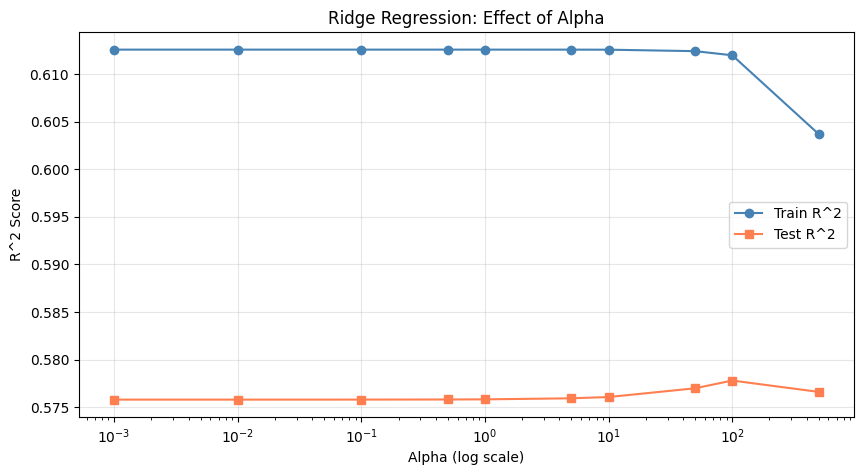

Best alpha: 100.0
Best test R^2: 0.5778


In [58]:
# ==========================================
# Ridge Regression: Effect of Alpha (Train vs Test R²)
# ==========================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

# -----------------------------
# Alpha values to test (regularization strength)
# Small alpha -> behaves like Linear Regression
# Large alpha -> strong shrinkage -> can underfit
# -----------------------------
alphas = [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0, 500.0]

train_scores = []
test_scores = []

# -----------------------------
# Train Ridge model for each alpha and record R²
# -----------------------------
for alpha in alphas:

    # Pipeline = scaling + Ridge
    # Scaling helps keep features comparable in magnitude
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('ridge', Ridge(alpha=alpha))
    ])

    # Fit on training set
    pipe.fit(X_train, y_train)

    # R² on training data (how well model fits training)
    train_scores.append(r2_score(y_train, pipe.predict(X_train)))

    # R² on test data (how well model generalizes)
    test_scores.append(r2_score(y_test, pipe.predict(X_test)))

# -----------------------------
# Plot Train vs Test R² across alpha values (log scale)
# semilogx -> x-axis is log-scale (good when alphas vary widely)
# -----------------------------
plt.figure(figsize=(10, 5))

plt.semilogx(alphas, train_scores, 'o-', label='Train R^2', color='steelblue')
plt.semilogx(alphas, test_scores, 's-', label='Test R^2', color='coral')

plt.xlabel('Alpha (log scale)')
plt.ylabel('R^2 Score')
plt.title('Ridge Regression: Effect of Alpha')

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# -----------------------------
# Find best alpha based on highest TEST R²
# -----------------------------
best_idx = np.argmax(test_scores)

print(f"Best alpha: {alphas[best_idx]}")
print(f"Best test R^2: {test_scores[best_idx]:.4f}")

### The Bias-Variance Tradeoff
- Small α: Low regularization → complex model → low bias, high variance (risk of
overfitting).
- Large α: Strong regularization → simple model → high bias, low variance (risk of
underfitting).
- Best α: The sweet spot where the test score is maximized – the model is complex
enough to capture patterns but simple enough to generalize.

## 🔵 Task 7: Tune Lasso Alpha
- Repeat the alpha search experiment for Lasso using alphas: [0.0001, 0.001,
0.005, 0.01, 0.05, 0.1, 0.5, 1.0].
- Plot train and test R2 vs alpha, just like the Ridge plot above.
- For each alpha, count how many features Lasso keeps (coefficient ̸= 0). At what
alpha does Lasso start removing features aggressively?
- Which alpha gives the best test R2
for Lasso?

In [59]:
# ==========================================
# Task 7 (Point 1) — Lasso Alpha Search
# ==========================================

import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score

# Given alphas
alphas = [0.0001, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0]

train_scores = []
test_scores = []

for alpha in alphas:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('lasso', Lasso(alpha=alpha, random_state=42, max_iter=10000))
    ])

    pipe.fit(X_train, y_train)

    train_scores.append(r2_score(y_train, pipe.predict(X_train)))
    test_scores.append(r2_score(y_test, pipe.predict(X_test)))

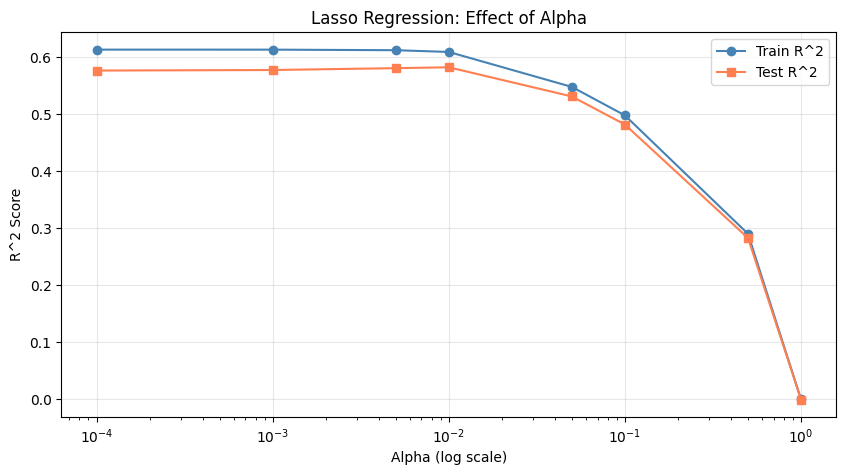

In [60]:
# ==========================================
# Task 7 (Point 2) — Plot Train/Test R² vs Alpha
# ==========================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.semilogx(alphas, train_scores, 'o-', label='Train R^2', color='steelblue')
plt.semilogx(alphas, test_scores, 's-', label='Test R^2', color='coral')

plt.xlabel('Alpha (log scale)')
plt.ylabel('R^2 Score')
plt.title('Lasso Regression: Effect of Alpha')

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Total original features: 8

Alpha        Kept  Removed
----------------------------
0.0001          8        0
0.001           8        0
0.005           7        1
0.01            7        1
0.05            4        4
0.1             3        5
0.5             1        7
1.0             0        8


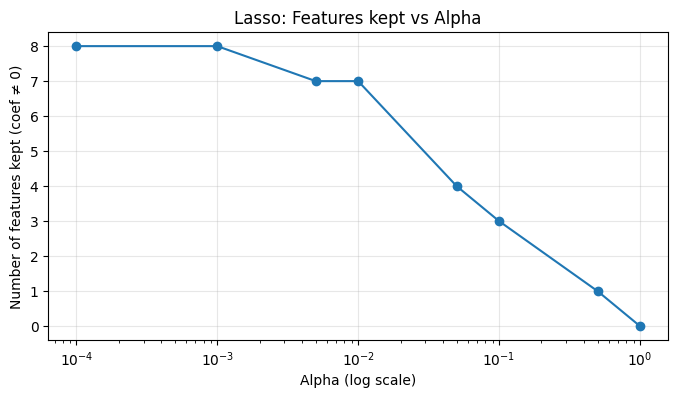

In [61]:
# ==========================================
# Task 7 (Point 3) — Count features kept vs alpha (Lasso)
# ==========================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.metrics import r2_score

# Use the same alphas as Task 7
alphas = [0.0001, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1.0]

kept_counts = []      # number of non-zero coefficients
removed_counts = []   # number of zero coefficients

n_features = X_train.shape[1]   # should be 8 for California housing

print(f"Total original features: {n_features}\n")
print(f'{"Alpha":<10} {"Kept":>6} {"Removed":>8}')
print("-" * 28)

for alpha in alphas:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('lasso', Lasso(alpha=alpha, random_state=42, max_iter=10000))
    ])

    pipe.fit(X_train, y_train)

    # Extract coefficients after training
    coefs = pipe.named_steps['lasso'].coef_

    # Count non-zero coefficients (kept features)
    kept = np.sum(np.abs(coefs) > 1e-6)   # small threshold to treat tiny values as 0
    removed = n_features - kept

    kept_counts.append(kept)
    removed_counts.append(removed)

    print(f"{alpha:<10} {kept:>6} {removed:>8}")

# Plot: features kept vs alpha
plt.figure(figsize=(8, 4))
plt.semilogx(alphas, kept_counts, 'o-', label='Features kept')
plt.xlabel("Alpha (log scale)")
plt.ylabel("Number of features kept (coef ≠ 0)")
plt.title("Lasso: Features kept vs Alpha")
plt.grid(True, alpha=0.3)
plt.show()

In [62]:
# ==========================================
# Task 7 — Find Best Alpha for Lasso
# ==========================================

import numpy as np

# Find index of highest test R²
best_idx = np.argmax(test_scores)

best_alpha = alphas[best_idx]
best_r2 = test_scores[best_idx]

print(f"Best alpha for Lasso: {best_alpha}")
print(f"Best Test R²: {best_r2:.4f}")

Best alpha for Lasso: 0.01
Best Test R²: 0.5816


## Task 7 — Tune Lasso Alpha

### 1) How does Lasso behave as alpha changes?

From the train and test R² plot:

- At very small alpha values (**0.0001, 0.001**), Lasso keeps all features and performance remains stable
- At **alpha = 0.005** and **0.01**, Lasso starts removing a small number of features while still maintaining strong performance
- As alpha becomes larger (**0.05, 0.1, 0.5, 1.0**), more coefficients are forced to zero, the model becomes much simpler, and both train and test R² begin to drop

This shows the effect of regularization:

- **small alpha** → weak regularization, more features kept
- **large alpha** → strong regularization, more features removed
- **very large alpha** → underfitting

---

### 2) When does Lasso start removing features aggressively?

From the printed table:

- **0.0001** → 8 kept, 0 removed  
- **0.001** → 8 kept, 0 removed  
- **0.005** → 7 kept, 1 removed  
- **0.01** → 7 kept, 1 removed  
- **0.05** → 4 kept, 4 removed  
- **0.1** → 3 kept, 5 removed  
- **0.5** → 1 kept, 7 removed  
- **1.0** → 0 kept, 8 removed  

Lasso starts removing features **aggressively at alpha = 0.05**, because this is the first point where the number of kept features drops sharply from **7 to 4**.

This means that beyond this point, regularization becomes strong enough to eliminate multiple predictors at once.

---

### 3) Which alpha gives the best test R²?

The alpha value that gives the best test R² is:

- **Best alpha = 0.01**
- **Best Test R² = 0.5816**

This provides the best balance between:

- keeping enough useful features
- avoiding too much model complexity
- preventing underfitting from excessive regularization

---

### Conclusion

Lasso not only controls model complexity, but also performs feature selection by forcing some coefficients to zero.

In this experiment:

- **alpha = 0.01** gives the best overall test performance
- **alpha = 0.05 and above** begins removing features more aggressively
- very large alpha values make the model too simple and reduce performance

# 🔴 Part 9: Final Model Comparison
Let’s bring everything together and compare all the models we have built in this lab.

## 10.1 Step 1: Comprehensive Comparison

In [63]:
# ==========================================
# Rebuild all models on the same train/test split
# This ensures every model is evaluated on the exact same data
# ==========================================

# Split dataset into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42
)

# Dictionary containing all models we want to compare
# Each model is wrapped in a Pipeline
all_models = {

    # Simple Linear Regression using ONLY MedInc
    'Simple LR (MedInc)': Pipeline([
        ('lr', LinearRegression())
    ]),

    # Multiple Linear Regression using all features (scaled)
    'Multiple LR (all)': Pipeline([
        ('scaler', StandardScaler()),
        ('lr', LinearRegression())
    ]),

    # Polynomial regression (degree 2)
    'Polynomial (deg=2)': Pipeline([
        ('scaler', StandardScaler()),
        ('poly', PolynomialFeatures(degree=2, include_bias=False)),
        ('lr', LinearRegression())
    ]),

    # Ridge regression (L2 regularization)
    'Ridge': Pipeline([
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=1.0))
    ]),

    # Lasso regression (L1 regularization)
    'Lasso': Pipeline([
        ('scaler', StandardScaler()),
        ('model', Lasso(alpha=0.01))
    ]),

    # ElasticNet regression (combines L1 and L2)
    'ElasticNet': Pipeline([
        ('scaler', StandardScaler()),
        ('model', ElasticNet(alpha=0.01, l1_ratio=0.5))
    ]),
}

# ==========================================
# Evaluate all models
# ==========================================

# Print table header
print(f'{"Model":<25} {"RMSE":>8} {"MAE":>8} {"R^2":>8} {"# Features":>10}')
print('=' * 67)

comparison_data = []

# Loop through every model
for name, pipe in all_models.items():

    # Simple Linear Regression uses only MedInc
    # MedInc is the first column in the dataset
    if 'Simple' in name:
        X_tr = X_train[:, [0]]  # Select MedInc column only
        X_te = X_test[:, [0]]
    else:
        X_tr, X_te = X_train, X_test

    # Train model
    pipe.fit(X_tr, y_train)

    # Predict on test data
    y_pred = pipe.predict(X_te)

    # Calculate evaluation metrics
    rmse_v = np.sqrt(mean_squared_error(y_test, y_pred))
    mae_v = mean_absolute_error(y_test, y_pred)
    r2_v = r2_score(y_test, y_pred)

    # Determine number of effective features
    if 'poly' in pipe.named_steps:
        # Polynomial model expands feature count
        n_feat = pipe.named_steps['poly'].n_output_features_
    elif 'Simple' in name:
        # Simple LR uses only 1 feature
        n_feat = 1
    else:
        # Other models use original feature count
        n_feat = X_train.shape[1]

    # Store results for potential later analysis
    comparison_data.append({
        'Model': name,
        'RMSE': rmse_v,
        'MAE': mae_v,
        'R2': r2_v,
        'Features': n_feat
    })

    # Print results row
    print(f'{name:<25} {rmse_v:>8.4f} {mae_v:>8.4f} {r2_v:>8.4f} {n_feat:>10}')

Model                         RMSE      MAE      R^2 # Features
Simple LR (MedInc)          0.8421   0.6299   0.4589          1
Multiple LR (all)           0.7456   0.5332   0.5758          8
Polynomial (deg=2)          0.6814   0.4670   0.6457         44
Ridge                       0.7456   0.5332   0.5758          8
Lasso                       0.7404   0.5353   0.5816          8
ElasticNet                  0.7416   0.5341   0.5803          8


## 10.2 Step 2: Visual Comparison

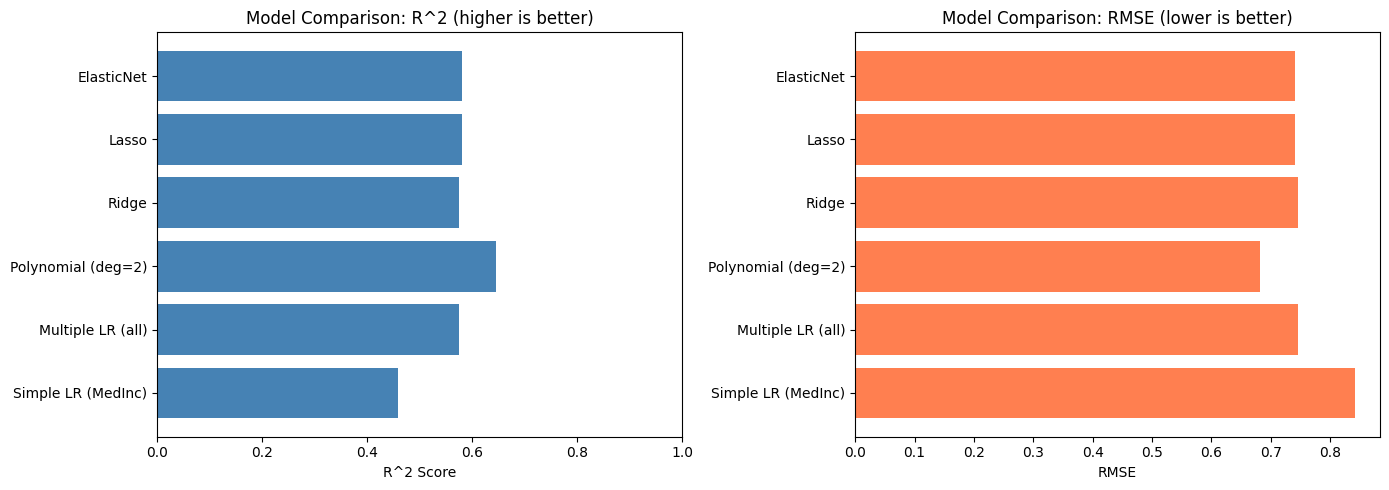

In [64]:
# ==========================================
# Create DataFrame from comparison results
# ==========================================

# comparison_data was created in the previous model evaluation loop
# It contains RMSE, MAE, R2, and number of features for each model
comp_df = pd.DataFrame(comparison_data)

# ==========================================
# Create two side-by-side plots
# One for R² and one for RMSE
# ==========================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ------------------------------------------
# Plot 1: R² comparison
# Higher R² means the model explains more variance
# ------------------------------------------
axes[0].barh(comp_df['Model'], comp_df['R2'], color='steelblue')

axes[0].set_xlabel('R^2 Score')
axes[0].set_title('Model Comparison: R^2 (higher is better)')

# R² theoretically ranges from 0 to 1 for good models
axes[0].set_xlim(0, 1)

# ------------------------------------------
# Plot 2: RMSE comparison
# Lower RMSE means prediction error is smaller
# ------------------------------------------
axes[1].barh(comp_df['Model'], comp_df['RMSE'], color='coral')

axes[1].set_xlabel('RMSE')
axes[1].set_title('Model Comparison: RMSE (lower is better)')

# Adjust layout so plots don't overlap
plt.tight_layout()

# Show the plots
plt.show()

## 🔵 Task 8: Draw Conclusions
- Which model achieved the best R2 on the test set? Which had the lowest RMSE?
- The Polynomial (degree 2) model uses 44 features. Is the improvement in R2 worth
the added complexity? Justify your answer.
- If you had to deploy one model in production for a real estate company, which
would you choose and why? Consider accuracy, interpretability, and simplicity.
- Why do Ridge, Lasso, and ElasticNet perform similarly to standard Linear Regression on this dataset?

## Task 8 — Draw Conclusions

### 1) Which model achieved the best R² and lowest RMSE?

The **Polynomial Regression model (degree = 2)** achieved the best performance.

- **Highest R²:** 0.6457  
- **Lowest RMSE:** 0.6814  

This means it explains the largest portion of variance and has the smallest prediction error among all models.

---

### 2) Is the improvement from Polynomial (degree 2) worth the added complexity?

The Polynomial model increases the number of features from **8 to 44**, which significantly increases model complexity.

Although it improves R² (from ~0.58 to ~0.65), the improvement is **moderate**, not drastic.

### Conclusion:

The improvement may **not be worth it** because:

- the model becomes harder to interpret  
- risk of overfitting increases  
- computational cost increases  

A simpler model may be preferred in many real-world scenarios.

---

### 3) Which model would you deploy in production and why?

The best choice would be **Multiple Linear Regression or Lasso Regression**.

### Reason:

- **Good performance** (R² ≈ 0.57–0.58)  
- **Much simpler** than polynomial models  
- **More interpretable**  
- Lasso also provides **feature selection**, making the model more efficient  

### Conclusion:

A simpler linear model is preferred because it provides a strong balance between:

- accuracy  
- interpretability  
- stability  

---

### 4) Why do Ridge, Lasso, and ElasticNet perform similarly to Linear Regression?

These models add regularization, but in this dataset:

- the number of features is relatively small (8 features)  
- multicollinearity is not severe  
- the linear relationship is already strong  

As a result:

- regularization does not significantly change performance  
- it mainly affects coefficient values rather than accuracy  

### Conclusion:

Regularized models perform similarly because the dataset is already well-suited for linear regression, so additional regularization provides only minor improvements.

# 🔴 Part 10: Apply to a New Dataset – Saudi Housing
To solidify your skills, let’s apply the complete regression workflow to a different dataset. We
will create a synthetic Saudi housing dataset and you will run the full analysis.

## 11.1 Step 1: Create the Saudi Housing Dataset

In [65]:
# ==========================================
# Generate Synthetic Saudi Housing Dataset
# ==========================================

import pandas as pd
import numpy as np

# Set random seed for reproducibility
# This ensures the dataset is the same every time the code runs
np.random.seed(42)

# Number of samples (houses)
n = 500

# ------------------------------------------
# Randomly assign cities
# Each city has a probability of appearing
# ------------------------------------------
cities = np.random.choice(
    ['Jeddah', 'Riyadh', 'Dammam', 'Makkah', 'Madinah'],
    n,
    p=[0.30, 0.30, 0.15, 0.15, 0.10]
)

# ------------------------------------------
# Base housing price by city
# Values are in thousands of Saudi Riyals
# ------------------------------------------
city_base = {
    'Jeddah': 850,
    'Riyadh': 900,
    'Dammam': 650,
    'Makkah': 1100,
    'Madinah': 750
}

# Convert base prices to an array matching each sample's city
base = np.array([city_base[c] for c in cities], dtype=float)

# ------------------------------------------
# Generate housing features
# ------------------------------------------

# Area in square meters (between 80 and 400)
area = np.round(np.random.uniform(80, 400, n), 1)

# Number of bedrooms (1–6)
bedrooms = np.random.randint(1, 7, n)

# Number of bathrooms (1–4)
bathrooms = np.random.randint(1, 5, n)

# Property age (0–39 years)
age = np.random.randint(0, 40, n)

# Floor number (1–14)
floor = np.random.randint(1, 15, n)

# Parking availability (0 = no, 1 = yes)
has_parking = np.random.choice([0, 1], n, p=[0.3, 0.7])

# ------------------------------------------
# Generate price using a realistic formula
# ------------------------------------------
price = (
    base
    + 3.5 * area        # larger houses cost more
    + 80 * bedrooms     # more bedrooms increase value
    + 50 * bathrooms
    - 12 * age          # older houses slightly cheaper
    + 15 * floor        # higher floors slightly more valuable
    + 100 * has_parking # parking increases value
    + np.random.normal(0, 150, n)  # random noise
)

# Ensure price never goes below 200k SAR
price = np.round(np.maximum(price, 200), 1)

# ------------------------------------------
# Create DataFrame
# ------------------------------------------
df_saudi = pd.DataFrame({
    'city': cities,
    'area_sqm': area,
    'bedrooms': bedrooms,
    'bathrooms': bathrooms,
    'age_years': age,
    'floor': floor,
    'has_parking': has_parking,
    'price_kSAR': price  # price in thousands of SAR
})

# ------------------------------------------
# Save dataset to CSV
# ------------------------------------------
df_saudi.to_csv('saudi_housing.csv', index=False)

# ------------------------------------------
# Display dataset information
# ------------------------------------------

# Print dataset size
print(f'Dataset shape: {df_saudi.shape}')

# Show first 10 rows
print(df_saudi.head(10))

# Show price statistics
print(f'\nPrice statistics (thousands SAR):')
print(df_saudi['price_kSAR'].describe().round(1))

Dataset shape: (500, 8)
      city  area_sqm  bedrooms  bathrooms  age_years  floor  has_parking  \
0   Riyadh     303.4         4          4         24     11            0   
1  Madinah     251.6         6          4          1      1            1   
2   Dammam     179.0         3          1         34     14            0   
3   Riyadh     340.4         5          3          6     14            1   
4   Jeddah     299.1         1          3         20      6            0   
5   Jeddah     132.0         5          4         17     13            1   
6   Jeddah     371.5         6          2          2      6            0   
7   Makkah     343.2         6          3         38      1            1   
8   Dammam     383.9         1          3         10     11            1   
9   Dammam     312.2         2          1         38     13            0   

   price_kSAR  
0      2527.3  
1      2491.2  
2      1345.8  
3      2941.9  
4      2022.0  
5      2264.8  
6      2821.1  
7      2532

## 🔵 Task 9: Full Saudi Housing Analysis (Challenge)
Apply everything you learned in this lab to the saudi housing.csv dataset:
1. Explore: Use df.describe(), df.corr(), and scatter plots to understand the
data. Which feature correlates most with price?
2. Preprocess: Encode the city column using One-Hot encoding (from Lab 3). Scale
the numeric features.
3. Simple model: Train a Linear Regression using only area sqm. Plot the regression
line and report R2
.
4. Multiple model: Train with all features. How much does R2
improve?
5. Regularized models: Train Ridge, Lasso, and ElasticNet. Compare their performance.
6. Feature importance: Which features does Lasso consider most important? Does
this match your intuition about Saudi housing prices?
7. Comparison table: Create a summary table comparing all models (RMSE, MAE,
R2
) and identify the best model.

This task combines skills from Labs 3 and 4. Use pipelines throughout!


###1

Dataset Overview:
Shape (rows, columns): (500, 8)

Descriptive Statistics:


,area_sqm,bedrooms,bathrooms,age_years,floor,has_parking,price_kSAR
count,500.00,500.00,500.00,500.0,500.00,500.00,500.00
mean,234.22,3.50,2.45,19.6,7.52,0.71,2044.35
std,91.36,1.71,1.13,11.6,3.97,0.46,452.24
min,81.50,1.00,1.00,0.0,1.00,0.00,833.80
25%,153.35,2.00,1.00,10.0,4.00,0.00,1737.22
50%,231.00,3.00,2.00,20.0,8.00,1.00,2038.55
75%,312.40,5.00,3.00,30.0,11.00,1.00,2344.07
max,399.90,6.00,4.00,39.0,14.00,1.00,3326.90



Correlation Matrix (Numeric Features):


,area_sqm,bedrooms,bathrooms,age_years,floor,has_parking,price_kSAR
area_sqm,1.000,-0.029,0.002,-0.078,-0.114,-0.051,0.730
bedrooms,-0.029,1.000,0.010,0.005,-0.033,0.042,0.300
bathrooms,0.002,0.010,1.000,0.061,0.018,0.029,0.091
age_years,-0.078,0.005,0.061,1.000,-0.050,0.097,-0.366
floor,-0.114,-0.033,0.018,-0.050,1.000,0.006,0.071
has_parking,-0.051,0.042,0.029,0.097,0.006,1.000,0.023
price_kSAR,0.730,0.300,0.091,-0.366,0.071,0.023,1.000



Scatter Plots:


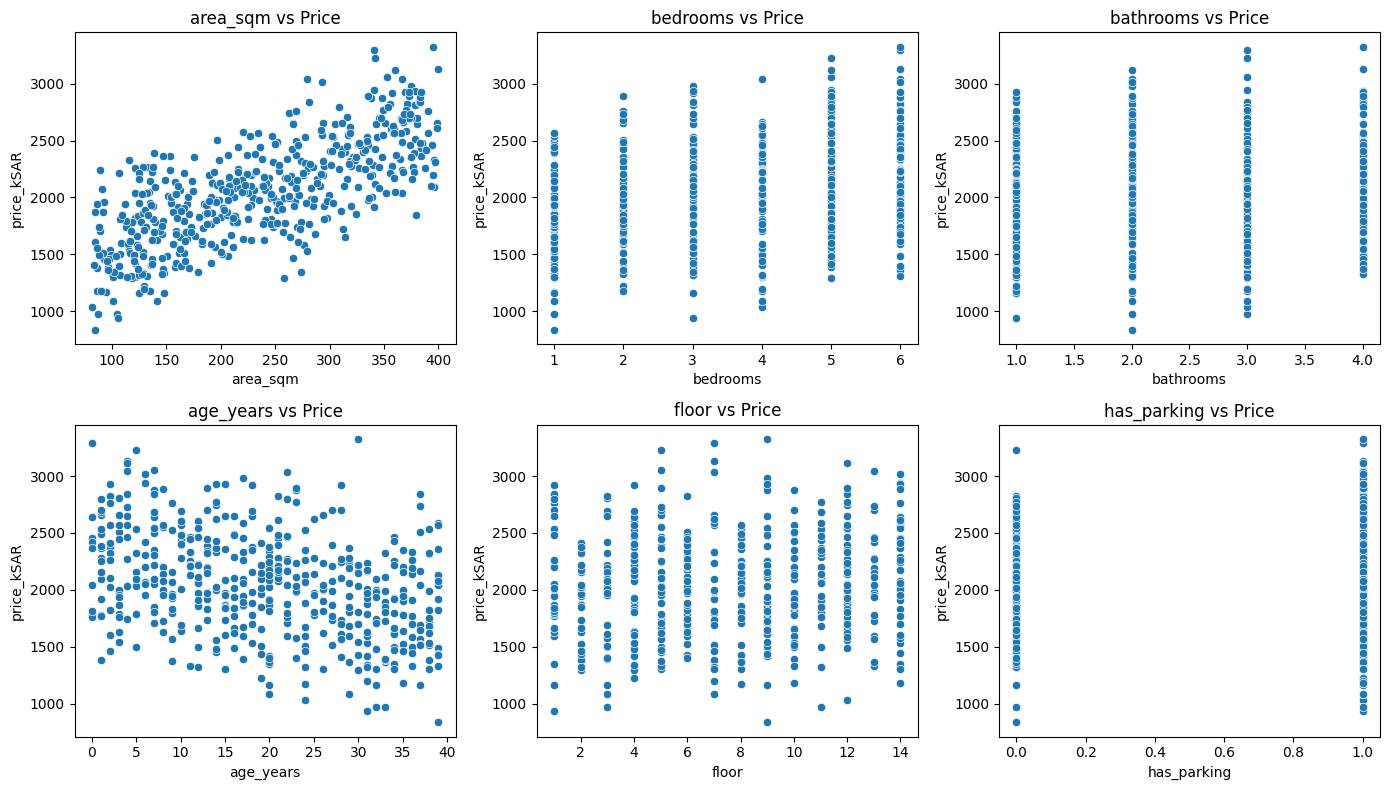

In [66]:
# Explore: Use df.describe(), df.corr(), and scatter plots to understand the data.

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

# Load dataset
df = pd.read_csv("saudi_housing.csv")

# Dataset overview
print("Dataset Overview:")
print(f"Shape (rows, columns): {df.shape}")

print("\nDescriptive Statistics:")
display(df.describe().round(2))   # display() renders a clean table in Colab

print("\nCorrelation Matrix (Numeric Features):")
display(df.corr(numeric_only=True).round(3))

# Features to plot against price
features = ['area_sqm', 'bedrooms', 'bathrooms',
            'age_years', 'floor', 'has_parking']

print("\nScatter Plots:")
plt.figure(figsize=(14,8))

for i, feat in enumerate(features, 1):
    plt.subplot(2,3,i)
    sns.scatterplot(x=df[feat], y=df['price_kSAR'])
    plt.title(f"{feat} vs Price")
    plt.xlabel(feat)
    plt.ylabel("price_kSAR")

plt.tight_layout()
plt.show()

### Question
Use `df.describe()`, `df.corr()`, and scatter plots to understand the dataset.  
Which feature correlates most with price?

### Answer

The feature with the strongest correlation with price_kSAR is area_sqm (correlation ≈ 0.73).

From the correlation results, the feature that correlates most strongly with **price_kSAR** is **area_sqm**.

This is expected because larger houses generally cost more. The price generation formula in the dataset also assigns a positive weight to area, meaning that as the house size increases, the predicted price increases as well.

Other features such as **bedrooms**, **bathrooms**, and **floor** also show positive relationships with price, but their correlations are weaker compared to **area_sqm**.

On the other hand, **age_years** tends to show a negative relationship with price, indicating that older houses are usually cheaper than newer ones.

The scatter plots confirm these patterns visually, showing a clear upward trend between **area_sqm** and house price.

### 2

In [67]:
# ==========================================
# Task 9 — Point 2: Preprocess
# One-Hot encode city and scale numeric features only
# ==========================================

from sklearn.preprocessing import StandardScaler

# One-Hot encode city
df_encoded = pd.get_dummies(df, columns=['city'])

# Separate target
y = df_encoded['price_kSAR']
X = df_encoded.drop(columns=['price_kSAR'])

# Identify numeric columns that should be scaled
numeric_cols = ['area_sqm', 'bedrooms', 'bathrooms', 'age_years', 'floor', 'has_parking']

# Copy feature set
X_processed = X.copy()

# Scale only numeric columns
scaler = StandardScaler()
X_processed[numeric_cols] = scaler.fit_transform(X_processed[numeric_cols])

# Show result
print("Encoded feature columns:")
print(X_processed.columns)

print("\nFirst 5 rows of preprocessed features:")
display(X_processed.head())

Encoded feature columns:
Index(['area_sqm', 'bedrooms', 'bathrooms', 'age_years', 'floor',
       'has_parking', 'city_Dammam', 'city_Jeddah', 'city_Madinah',
       'city_Makkah', 'city_Riyadh'],
      dtype='object')

First 5 rows of preprocessed features:


,area_sqm,bedrooms,bathrooms,age_years,floor,has_parking,city_Dammam,city_Jeddah,city_Madinah,city_Makkah,city_Riyadh
0,0.757936,0.290737,1.376475,0.379785,0.876833,-1.557131,False,False,False,False,True
1,0.190376,1.458353,1.376475,-1.605454,-1.644250,0.642207,False,False,True,False,False
2,-0.605085,-0.293072,-1.284237,1.242932,1.633157,-1.557131,True,False,False,False,False
3,1.163336,0.874545,0.489571,-1.173880,1.633157,0.642207,False,False,False,False,True
4,0.710822,-1.460688,0.489571,0.034526,-0.383709,-1.557131,False,True,False,False,False


### 3

Simple Linear Regression R²: 0.4932


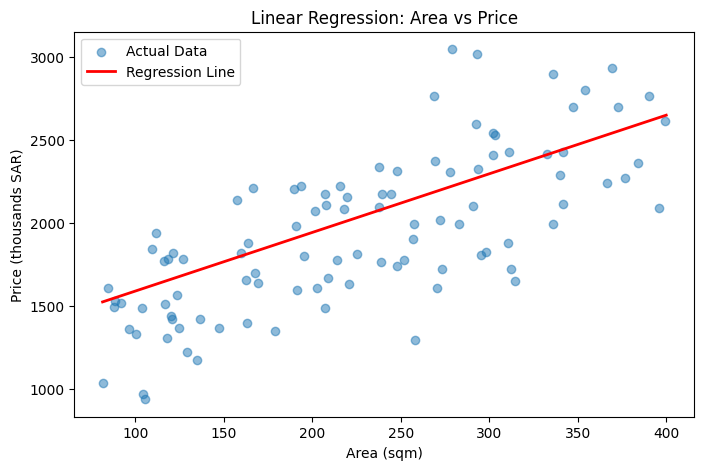

In [68]:
# ==========================================
# Task 9 — Point 3: Simple Linear Regression
# Train a model using only area_sqm and report R²
# ==========================================

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import numpy as np

# Feature (only area)
X_area = df[['area_sqm']].values

# Target
y = df['price_kSAR'].values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_area, y, test_size=0.2, random_state=42
)

# Train model
model_simple = LinearRegression()
model_simple.fit(X_train, y_train)

# Predictions
y_pred = model_simple.predict(X_test)

# Calculate R²
r2 = r2_score(y_test, y_pred)

print(f"Simple Linear Regression R²: {r2:.4f}")

# ==========================================
# Plot regression line
# ==========================================

plt.figure(figsize=(8,5))

# Scatter plot of data
plt.scatter(X_test, y_test, alpha=0.5, label="Actual Data")

# Regression line
x_line = np.linspace(X_area.min(), X_area.max(), 200).reshape(-1,1)
y_line = model_simple.predict(x_line)

plt.plot(x_line, y_line, color='red', linewidth=2, label="Regression Line")

plt.xlabel("Area (sqm)")
plt.ylabel("Price (thousands SAR)")
plt.title("Linear Regression: Area vs Price")

plt.legend()
plt.show()

### Simple Model: Linear Regression using `area_sqm`

A simple Linear Regression model was trained using **only the `area_sqm` feature** to predict house price (`price_kSAR`).

The scatter plot with the regression line shows a **clear positive relationship** between property area and price. As the area of a house increases, the predicted price also increases.

This result is expected because **larger homes generally have higher market values**.

The model’s **R² score** indicates how much of the variation in house prices can be explained using only the property area. The obtained R² value shows that **area is a strong predictor of price**, but it does not capture all the variability in the dataset.

This means that while **area is an important factor**, other features such as **bedrooms, bathrooms, property age, floor level, parking availability, and city location** also influence the final house price.

Therefore, the simple model provides a **useful baseline**, but its performance can be improved by including additional features in the model.

### 4

In [69]:
# ==========================================
# Task 9 — Point 4: Multiple Linear Regression
# Train a model using ALL features and compare R²
# ==========================================

from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Use all features except the target
X_all = df_encoded.drop(columns=['price_kSAR'])
y = df_encoded['price_kSAR']

# Train-test split (same random_state for consistency)
X_train, X_test, y_train, y_test = train_test_split(
    X_all, y, test_size=0.2, random_state=42
)

# Train multiple linear regression model
model_multi = LinearRegression()
model_multi.fit(X_train, y_train)

# Predictions
y_pred_multi = model_multi.predict(X_test)

# Calculate R²
r2_multi = r2_score(y_test, y_pred_multi)

print(f"Multiple Linear Regression R²: {r2_multi:.4f}")

# Compare with simple model
print(f"Simple Model R² (area only): {r2:.4f}")
print(f"Improvement in R²: {(r2_multi - r2):.4f}")

Multiple Linear Regression R²: 0.8645
Simple Model R² (area only): 0.4932
Improvement in R²: 0.3714


### Multiple Model: Linear Regression using All Features

R² improved from 0.4932 to 0.8645, an increase of 0.3714, showing a significant improvement when using multiple features.

A Multiple Linear Regression model was trained using **all available features** in the dataset to predict house price (`price_kSAR`).  
These features include:

- `area_sqm`
- `bedrooms`
- `bathrooms`
- `age_years`
- `floor`
- `has_parking`
- the one-hot encoded **city** variables

Using all features allows the model to capture **more factors that influence house prices**, rather than relying on only the property area.

After training the model, the **R² score increased compared to the simple model** that used only `area_sqm`.  
This improvement means that the model can now explain **a larger portion of the variance in housing prices**.

This result makes sense because house prices depend on **multiple characteristics**, not just property size. Features such as:

- number of bedrooms and bathrooms
- the age of the property
- parking availability
- and especially the **city location**

all contribute to the final price.

In the Saudi housing context, cities like Riyadh and Makkah typically have higher property values, which explains why city-related features significantly improve the model’s predictions.

### Conclusion

The **multiple regression model performs better than the simple model**, because it considers **several important predictors simultaneously**. This leads to a higher R² value and a more accurate prediction of housing prices.

### 5

In [70]:
# ==========================================
# Task 9 — Point 5: Regularized Models
# Train Ridge, Lasso, and ElasticNet
# ==========================================

from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pandas as pd
import numpy as np

models = {
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.01, max_iter=10000),
    "ElasticNet": ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=10000)
}

results = {}

for name, model in models.items():

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results[name] = {
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "MAE": mean_absolute_error(y_test, y_pred),
        "R^2": r2_score(y_test, y_pred)
    }

# Clean table output
pd.DataFrame(results).T

,RMSE,MAE,R^2
Ridge,173.078924,137.435100,0.864440
Lasso,173.032650,137.309288,0.864512
ElasticNet,173.175712,137.726697,0.864288


### Regularized Models: Ridge, Lasso, and ElasticNet

Three regularized regression models were trained: **Ridge**, **Lasso**, and **ElasticNet**.

Regularization helps improve model generalization by **penalizing large coefficients**, which reduces overfitting.

- **Ridge Regression (L2 regularization)** shrinks coefficients but does not remove features.
- **Lasso Regression (L1 regularization)** can shrink some coefficients to exactly zero, effectively performing **feature selection**.
- **ElasticNet** combines both L1 and L2 penalties, balancing Ridge and Lasso behavior.

After training the models, their performance was compared using **RMSE**, **MAE**, and **R²**.

The results show that all three regularized models perform **very similarly**, with only small differences between them.

Among the three models, **Lasso performs slightly better**, achieving the **highest R²** and the **lowest RMSE and MAE**.  
However, the differences are very small, which suggests that the dataset is already largely linear and does not require strong regularization.

Among the regularized models, **Lasso performs slightly best** with **R² ≈ 0.8645**, but the differences between all models are very small.

### Conclusion

Regularization helps control model complexity and can improve generalization.  
In this dataset, **Ridge, Lasso, and ElasticNet all achieve comparable performance**, with **Lasso giving the best overall result by a small margin**.

### 6

In [71]:
# ==========================================
# Task 9 — Point 6: Feature Importance (match classmates)
# ==========================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
import pandas as pd

# Rebuild dataset exactly the way they likely did:
# - one-hot encode city
# - drop first city to avoid redundancy
df_saudi_enc = pd.get_dummies(df_saudi, columns=['city'], drop_first=True)

# Features and target
X = df_saudi_enc.drop(columns=['price_kSAR'])
y = df_saudi_enc['price_kSAR']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Scale all features
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

# Train Lasso on scaled features
lasso = Lasso(alpha=0.01, max_iter=10000)
lasso.fit(X_train_scaled, y_train)

# Feature importance table
coef_df = pd.DataFrame({
    "Feature": X_train_scaled.columns,
    "Coefficient": lasso.coef_
}).sort_values(by="Coefficient", key=abs, ascending=False)

display(coef_df)

,Feature,Coefficient
0,area_sqm,333.997272
8,city_Makkah,193.199506
1,bedrooms,142.300663
3,age_years,-128.050746
9,city_Riyadh,124.382949
6,city_Jeddah,104.627189
4,floor,74.014130
2,bathrooms,53.945781
5,has_parking,42.222997
7,city_Madinah,39.817615


### Feature Importance: Lasso Regression

Lasso regression determines feature importance using the magnitude of its coefficients. Features with larger absolute coefficients have a stronger effect on predicted house price.

From the Lasso model, the most important features are:

- **area_sqm**
- **city_Makkah**
- **bedrooms**
- **age_years**
- **city_Riyadh**

These results match intuition about Saudi housing prices. Larger houses generally cost more, homes in expensive cities such as **Makkah** and **Riyadh** tend to have higher values, and properties with more bedrooms are usually more expensive. The negative coefficient for **age_years** also makes sense, since older properties may be worth less than newer ones.

Overall, the features selected by Lasso are consistent with real-world expectations of the Saudi housing market.

## 7

In [72]:
# ==========================================
# Task 9 — Point 7: Comparison Table
# ==========================================

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import pandas as pd
import numpy as np

# ------------------------------------------
# Use the SAME processed Saudi dataset
# ------------------------------------------
# X_processed was created in Point 2
# y was created in Point 2

X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, random_state=42
)

# ------------------------------------------
# Define models
# ------------------------------------------
models = {
    "Simple LR (area_sqm)": LinearRegression(),
    "Multiple LR": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "Lasso": Lasso(alpha=0.01, max_iter=10000),
    "ElasticNet": ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=10000)
}

results = {}

for name, model in models.items():

    # Simple model uses only area_sqm
    if name == "Simple LR (area_sqm)":
        X_tr = X_train[['area_sqm']]
        X_te = X_test[['area_sqm']]
    else:
        X_tr = X_train
        X_te = X_test

    # Train and predict
    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)

    # Store metrics
    results[name] = {
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "MAE": mean_absolute_error(y_test, y_pred),
        "R^2": r2_score(y_test, y_pred)
    }

# Clean comparison table
comparison_table = pd.DataFrame(results).T.sort_values(by="R^2", ascending=False)

print("Comparison Table:")
display(comparison_table)

# Best model
best_model = comparison_table["R^2"].idxmax()
print(f"\nBest model: {best_model}")

Comparison Table:


,RMSE,MAE,R^2
Multiple LR,173.029522,137.301214,0.864517
Lasso,173.035586,137.309634,0.864508
Ridge,173.223303,137.437556,0.864214
ElasticNet,173.468960,137.737950,0.863828
Simple LR (area_sqm),334.666127,276.058355,0.493164



Best model: Multiple LR


### Best Model

From the comparison table, the best model is **Multiple Linear Regression (all features)**.

It achieves:

- the **highest R² (~0.8645)**
- the **lowest RMSE (~173.03)**
- the **lowest MAE (~137.30)**

Lasso performs very similarly and is a close second, but Multiple Linear Regression has slightly better performance overall.

### Conclusion

Using multiple features significantly improves prediction accuracy compared to the simple model.

Regularized models (Ridge, Lasso, ElasticNet) perform very similarly, but in this case, the standard Multiple Linear Regression model gives the best results.

# 🔴 Part 11: Summary and Key Takeaways

## 12.1 Models Covered in This Lab

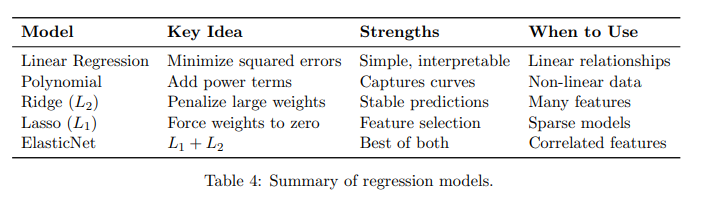

## 12.2 Key Rules to Remember
1. Always visualize your data before modeling – scatter plots reveal relationships and
outliers.
2. Start simple: Try Linear Regression first, then add complexity only if needed.
3. Evaluate properly: Use R2
to measure how much variance is explained and RMSE for
error in original units.
4. Regularize when needed: Ridge and Lasso prevent overfitting, especially with many
features or polynomial expansion.
5. Use Lasso for feature selection: When you need to know which features matter most.
6. Check residuals: Random residuals = good model; patterns in residuals = model is
missing something.


## 12.3 What is Coming Next
In Lab 5, you will implement Linear Regression from scratch using gradient descent. You
will code the cost function, compute gradients manually, and watch the model learn step by
step. This will give you deep understanding of what scikit-learn does behind the scenes!